# Processing cell-attached spiking data for each motoneuron

In [75]:
# parent_folder_path = "/Users/haleyoro/Desktop/" # work on library computer
parent_folder_path = "/Users/Haley/Desktop/" # work on local computer

In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyabf
import os
from waveforms_helpers import *
import pickle
from cellattachedspikes import *

In [77]:
with open("sheets.pkl", "rb") as f:
    sheets = pickle.load(f)

In [6]:
sheets.keys()

dict_keys(['2012_04_25_cell1', '2012_04_25_cell3', '2012_04_27_cell1', '2012_06_22_cell3', '2012_06_25_cell3', '2012_06_29', '2012_08_01_cell1', '2012_08_01_cell3', '2012_08_07', '2012_08_31_cell1', '2012_08_31_cell2', '2012_08_31_cell3', '2012_08_31_cell4', '2012_10_04_cell2', '2012_12_03_cell1', '2012_12_04_cell1', '2012_12_04_cell2', '2012_12_05_cell1', '2012_12_05_cell3', '2012_12_05_cell4', '2012_12_06_cell1', '2012_12_06_cell2', '2012_12_06_cell3', '2012_12_06_cell4', '2012_12_06_cell5', '2012_12_06_cell6', '2013_03_20_cell1', '2013_03_21_cell1', '2013_03_21_cell2', '2013_03_21_cell3', '2013_03_21_cell4', '2013_03_21_cell5', '2013_03_22_cell1', '2013_03_22_cell2', '2013_03_22_cell3', '2013_03_22_cell4', '2013_03_22_cell5', '2013_03_22_cell6', '2012_10_04_cell1'])

In [7]:
sheets['2012_04_25_cell1']

,Trace name,ID,On time,Freq,Tags,Type,Seconds,Cell Type,Input Resistance,Motoneuron
0,2012_04_25_0004,1,1285.99,NaN,bout start; shock,Inhibitory,1.28599,vRoP,74.45,primary
1,2012_04_25_0004,2,1305.92,50.1756,<NA>,Inhibitory,1.30592,vRoP,74.45,primary
2,2012_04_25_0004,3,1340.95,28.5470,<NA>,Inhibitory,1.34095,vRoP,74.45,primary
3,2012_04_25_0004,4,1371.30,32.9489,<NA>,Inhibitory,1.37130,vRoP,74.45,primary
4,2012_04_25_0004,5,1405.23,29.4724,bout end,Inhibitory,1.40523,vRoP,74.45,primary
...,...,...,...,...,...,...,...,...,...,...
153,2012_04_25_0002,13,4726.57,39.7141,<NA>,Excitatory,4.72657,vRoP,74.45,primary
154,2012_04_25_0002,14,4755.30,34.8068,<NA>,Excitatory,4.75530,vRoP,74.45,primary
155,2012_04_25_0002,15,4780.80,39.2157,<NA>,Excitatory,4.78080,vRoP,74.45,primary
156,2012_04_25_0002,16,4808.89,35.5999,<NA>,Excitatory,4.80889,vRoP,74.45,primary


In [13]:
matches, non_matches = split_cell_attached(sheets)

print("✅ Sheets WITH Cell-attached traces:")
for sheet, rows in matches.items():
    print(f"  - {sheet} ({len(rows)} rows)")

✅ Sheets WITH Cell-attached traces:
  - 2012_08_01_cell1 (126 rows)
  - 2012_08_01_cell3 (132 rows)
  - 2012_08_07 (54 rows)
  - 2012_08_31_cell1 (225 rows)
  - 2012_08_31_cell2 (811 rows)
  - 2012_08_31_cell3 (147 rows)
  - 2012_08_31_cell4 (110 rows)
  - 2012_10_04_cell2 (244 rows)
  - 2012_12_03_cell1 (172 rows)
  - 2012_12_04_cell1 (164 rows)
  - 2012_12_04_cell2 (108 rows)
  - 2012_12_05_cell1 (235 rows)
  - 2012_12_05_cell3 (349 rows)
  - 2012_12_05_cell4 (501 rows)
  - 2012_12_06_cell1 (102 rows)
  - 2012_12_06_cell2 (202 rows)
  - 2012_12_06_cell3 (343 rows)
  - 2012_12_06_cell4 (621 rows)
  - 2012_12_06_cell5 (346 rows)
  - 2012_12_06_cell6 (242 rows)
  - 2013_03_20_cell1 (267 rows)
  - 2013_03_21_cell1 (381 rows)
  - 2013_03_21_cell2 (690 rows)
  - 2013_03_21_cell3 (221 rows)
  - 2013_03_21_cell4 (1193 rows)
  - 2013_03_21_cell5 (316 rows)
  - 2013_03_22_cell1 (416 rows)
  - 2013_03_22_cell2 (565 rows)
  - 2013_03_22_cell4 (793 rows)
  - 2013_03_22_cell5 (258 rows)
  - 2013_0

In [14]:
print("\n❌ Sheets WITHOUT Cell-attached traces:")
for sheet in non_matches:
    print(f"  - {sheet}")



❌ Sheets WITHOUT Cell-attached traces:
  - 2012_04_25_cell1
  - 2012_04_25_cell3
  - 2012_04_27_cell1
  - 2012_06_22_cell3
  - 2012_06_25_cell3
  - 2012_06_29
  - 2013_03_22_cell3


In [ ]:
cell_attached_dict = filter_cell_attached(sheets)

print("New dictionary contains only Cell-attached / Cell-attached (spiking) rows from:")
for sheet, df in cell_attached_dict.items():
    print(f"  - {sheet}: {len(df)} rows")

New dictionary contains only Cell-attached / Cell-attached (spiking) rows from:
  - 2012_08_01_cell1: 170 rows
  - 2012_08_01_cell3: 224 rows
  - 2012_08_07: 141 rows
  - 2012_08_31_cell1: 321 rows
  - 2012_08_31_cell2: 911 rows
  - 2012_08_31_cell3: 185 rows
  - 2012_08_31_cell4: 134 rows
  - 2012_10_04_cell2: 340 rows
  - 2012_12_03_cell1: 684 rows
  - 2012_12_04_cell1: 277 rows
  - 2012_12_04_cell2: 211 rows
  - 2012_12_05_cell1: 288 rows
  - 2012_12_05_cell3: 701 rows
  - 2012_12_05_cell4: 1229 rows
  - 2012_12_06_cell1: 167 rows
  - 2012_12_06_cell2: 404 rows
  - 2012_12_06_cell3: 421 rows
  - 2012_12_06_cell4: 800 rows
  - 2012_12_06_cell5: 397 rows
  - 2012_12_06_cell6: 258 rows
  - 2013_03_20_cell1: 304 rows
  - 2013_03_21_cell1: 419 rows
  - 2013_03_21_cell2: 739 rows
  - 2013_03_21_cell3: 279 rows
  - 2013_03_21_cell4: 1218 rows
  - 2013_03_21_cell5: 379 rows
  - 2013_03_22_cell1: 498 rows
  - 2013_03_22_cell2: 639 rows
  - 2013_03_22_cell4: 911 rows
  - 2013_03_22_cell5: 312

In [18]:
with open("cell_attached_sheets.pkl", "wb") as f:
    pickle.dump(cell_attached_dict, f)

In [23]:
cell_attached_dict.keys()
cell_attached_dict['2012_08_01_cell1']

,Trace name,ID,On time,Freq,Tags,Type,Seconds,Cell Type,Input Resistance,Motoneuron
442,2012_08_01_0002,1,2181.54,NaN,bout start; shock,Cell-attached,2.18154,vSMN,287.0,Low Rin Secondary
443,2012_08_01_0002,2,2212.18,32.6371,<NA>,Cell-attached,2.21218,vSMN,287.0,Low Rin Secondary
444,2012_08_01_0002,3,2238.12,38.5505,<NA>,Cell-attached,2.23812,vSMN,287.0,Low Rin Secondary
445,2012_08_01_0002,4,2277.70,25.2653,<NA>,Cell-attached,2.27770,vSMN,287.0,Low Rin Secondary
446,2012_08_01_0002,5,2316.77,25.5951,<NA>,Cell-attached,2.31677,vSMN,287.0,Low Rin Secondary
...,...,...,...,...,...,...,...,...,...,...
607,2012_08_01_0003,21,6448.56,16.2575,<NA>,Cell-attached (spiking),6.44856,vSMN,287.0,Low Rin Secondary
608,2012_08_01_0003,22,8173.00,0.5799,<NA>,Cell-attached (spiking),8.17300,vSMN,287.0,Low Rin Secondary
609,2012_08_01_0003,23,8209.73,27.2257,<NA>,Cell-attached (spiking),8.20973,vSMN,287.0,Low Rin Secondary
610,2012_08_01_0003,24,8381.96,5.8062,<NA>,Cell-attached (spiking),8.38196,vSMN,287.0,Low Rin Secondary


making sure frequency is correctly calculated

In [ ]:
updated = recalc_freq_cell_attached(cell_attached_dict['2012_08_01_cell1'])
print(updated[["ID", "Seconds", "Freq"]])

     ID  Seconds       Freq
442   1  2.18154        NaN
443   2  2.21218  32.637076
444   3  2.23812  38.550501
445   4  2.27770  25.265285
446   5  2.31677  25.595086
..   ..      ...        ...
607  21  6.44856  16.257500
608  22  8.17300   0.579900
609  23  8.20973  27.225700
610  24  8.38196   5.806200
611  25  8.76629   2.601900

[170 rows x 3 columns]


In [48]:
spikes = assign_spike_frequencies_for_dict(cell_attached_dict)
spikes

{'2012_08_01_cell1':          Trace name  trace_time  spike_frequency  burst_index
 0   2012_08_01_0002     2.24773        38.550501            3
 1   2012_08_01_0002     2.28153        25.265285            4
 2   2012_08_01_0002     2.31920        25.595086            5
 3   2012_08_01_0002     2.36224        20.746888            6
 4   2012_08_01_0002     2.40853        24.108004            7
 5   2012_08_01_0002     2.45127        22.872827            8
 6   2012_08_01_0002     2.54308        19.127774           10
 7   2012_08_01_0002     2.67411        20.738283           13
 8   2012_08_01_0002     2.71757        24.301337           14
 9   2012_08_01_0002     2.75876        25.169897           15
 10  2012_08_01_0002     2.79726        25.284450           16
 11  2012_08_01_0002     2.83865        25.406504           17
 12  2012_08_01_0002     2.97572        24.491795           20
 13  2012_08_01_0002     3.67887        27.173913           28
 14  2012_08_01_0002     3.85500   

In [ ]:
all_spikes = combine_spike_dict(spikes)
print(all_spikes.head())


        Trace name  trace_time  spike_frequency  burst_index              cell
0  2012_08_01_0002     2.24773        38.550501            3  2012_08_01_cell1
1  2012_08_01_0002     2.28153        25.265285            4  2012_08_01_cell1
2  2012_08_01_0002     2.31920        25.595086            5  2012_08_01_cell1
3  2012_08_01_0002     2.36224        20.746888            6  2012_08_01_cell1
4  2012_08_01_0002     2.40853        24.108004            7  2012_08_01_cell1


In [78]:
all_spikes_clean = clean_spikes_dataframe(all_spikes, min_freq=10)


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- helpers --------------------

def _validate_df(df: pd.DataFrame):
    required = {"cell", "spike_frequency"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

def order_cells_by_mean(df: pd.DataFrame) -> list[str]:
    """Return cells ordered by ascending mean spike frequency."""
    _validate_df(df)
    order = (
        df.dropna(subset=["spike_frequency"])
          .groupby("cell")["spike_frequency"]
          .mean()
          .sort_values(kind="mergesort")  # stable sort for consistent ties
          .index
          .tolist()
    )
    return order

# -------------------- plot 1: dash marks --------------------
def plot_spike_dashes(df: pd.DataFrame, cell_order: list[str] | None = None,
                      base_lw: float = 1.5, lw_scale: float = 0.8, dash_halfwidth: float = 0.35,
                      show_means: bool = True, show_medians: bool = True,
                      mean_color: str = "tab:orange", median_color: str = "tab:green",
                      marker_size: float = 40.0):
    """
    Dash for each spike frequency per cell.
    - Spikes are drawn as blue dashes.
    - If multiple spikes have the exact same frequency in a cell,
      the line width is increased proportionally.
    - Overlays mean and median as dots.
    - Adds error bars for mean ± standard deviation.
    """
    _validate_df(df)
    d = df.dropna(subset=["spike_frequency"]).copy()
    if cell_order is None:
        cell_order = order_cells_by_mean(d)

    # map cells to x positions
    xmap = {cell: i for i, cell in enumerate(cell_order, start=1)}

    fig, ax = plt.subplots(figsize=(max(8, len(cell_order) * 0.7), 5), constrained_layout=True)

    # For each cell, count duplicates of identical frequencies
    means, medians, stds, xs = [], [], [], []
    for cell in cell_order:
        sub = d[d["cell"] == cell]
        if sub.empty:
            continue
        counts = sub["spike_frequency"].round(10).value_counts()
        x = xmap[cell]
        for freq, cnt in counts.items():
            lw = base_lw + lw_scale * (np.sqrt(cnt) - 1.0)
            ax.hlines(y=freq, xmin=x - dash_halfwidth, xmax=x + dash_halfwidth,
                      linewidth=lw, color="tab:blue")

        # Collect stats for overlay
        means.append(sub["spike_frequency"].mean())
        medians.append(sub["spike_frequency"].median())
        stds.append(sub["spike_frequency"].std())
        xs.append(x)

    # Overlay stats
    if show_means:
        ax.errorbar(xs, means, yerr=stds, fmt='o', color=mean_color,
                    markersize=marker_size/10, label="Mean ± SD", capsize=4)
    if show_medians:
        ax.scatter(xs, medians, s=marker_size, color=median_color, label="Median")

    ax.set_title("Spike frequencies by cell — dash view (line width = multiplicity)")
    ax.set_ylabel("Spike frequency (Hz)")
    ax.set_xlabel("Cell")
    ax.set_xticks(list(xmap.values()))
    ax.set_xticklabels(cell_order, rotation=45, ha="right")
    if show_means or show_medians:
        ax.legend()
    plt.show()



# -------------------- plot 2: violins with median/mean dots --------------------

def plot_violins_with_stats(df: pd.DataFrame, cell_order: list[str] | None = None,
                            show_means: bool = True, show_medians: bool = True,
                            mean_color: str = "tab:orange", median_color: str = "tab:green",
                            marker_size: float = 40.0):
    """
    Violin plots per cell (matplotlib), with optional overlaid mean/median dots (different colors).
    """
    _validate_df(df)
    d = df.dropna(subset=["spike_frequency"]).copy()
    if cell_order is None:
        cell_order = order_cells_by_mean(d)

    data = [d.loc[d["cell"] == c, "spike_frequency"].to_numpy() for c in cell_order]

    fig, ax = plt.subplots(figsize=(max(8, len(cell_order) * 0.7), 5), constrained_layout=True)

    parts = ax.violinplot(data, showmeans=False, showmedians=False, showextrema=False)
    # Optionally tone down violins (leave default color if you prefer)
    for pc in parts['bodies']:
        pc.set_alpha(0.6)

    # Compute stats
    means = [np.nanmean(arr) if len(arr) else np.nan for arr in data]
    medians = [np.nanmedian(arr) if len(arr) else np.nan for arr in data]
    xs = np.arange(1, len(cell_order) + 1)

    # overlay stats
    if show_means:
        ax.scatter(xs, means, s=marker_size, color=mean_color, label="Mean")
    if show_medians:
        ax.scatter(xs, medians, s=marker_size, color=median_color, label="Median")

    ax.set_title("Spike frequencies by cell — violin view with mean/median")
    ax.set_ylabel("Spike frequency (Hz)")
    ax.set_xlabel("Cell")
    ax.set_xticks(xs)
    ax.set_xticklabels(cell_order, rotation=45, ha="right")
    if show_means or show_medians:
        ax.legend()
    plt.show()

# -------------------- plot 3: summary dots only (mean & median) --------------------

def plot_summary_dots(df: pd.DataFrame, cell_order: list[str] | None = None,
                      mean_color: str = "tab:orange", median_color: str = "tab:green",
                      marker_size: float = 50.0):
    """
    A clean summary: shows only mean and median dots per cell.
    """
    _validate_df(df)
    d = df.dropna(subset=["spike_frequency"]).copy()
    if cell_order is None:
        cell_order = order_cells_by_mean(d)

    agg = (d.groupby("cell")["spike_frequency"]
             .agg(mean="mean", median="median")
             .reindex(cell_order))

    xs = np.arange(1, len(cell_order) + 1)
    fig, ax = plt.subplots(figsize=(max(8, len(cell_order) * 0.7), 5), constrained_layout=True)

    ax.scatter(xs, agg["mean"].to_numpy(), s=marker_size, color=mean_color, label="Mean")
    ax.scatter(xs, agg["median"].to_numpy(), s=marker_size, color=median_color, label="Median")

    ax.set_title("Spike frequencies by cell — summary means/medians")
    ax.set_ylabel("Spike frequency (Hz)")
    ax.set_xlabel("Cell")
    ax.set_xticks(xs)
    ax.set_xticklabels(cell_order, rotation=45, ha="right")
    ax.legend()
    plt.show()

# -------------------- convenience: run all three --------------------

def plot_all_views(all_spikes_df: pd.DataFrame):
    """
    Orders cells by ascending mean frequency, then renders:
    1) dash view, 2) violin+stats, 3) summary dots.
    """
    _validate_df(all_spikes_df)
    ordered_cells = order_cells_by_mean(all_spikes_df)

    plot_spike_dashes(all_spikes_df, ordered_cells)
    plot_violins_with_stats(all_spikes_df, ordered_cells)
    plot_summary_dots(all_spikes_df, ordered_cells)


In [ ]:
plot_boxplot_spike_freq(all_spikes_clean, order_by="mean")
plot_strip_spike_freq(all_spikes_clean, order_by="median")

TypeError: plot_boxplot_spike_freq() got an unexpected keyword argument 'order_by'

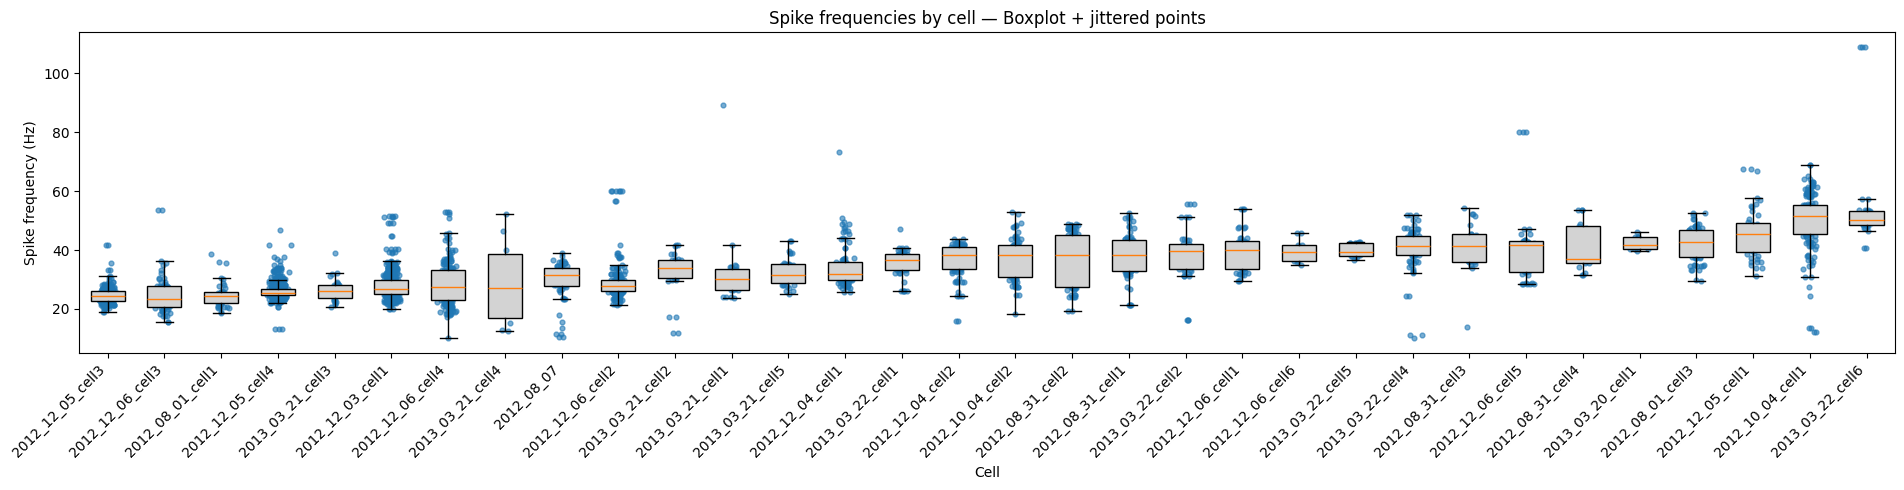

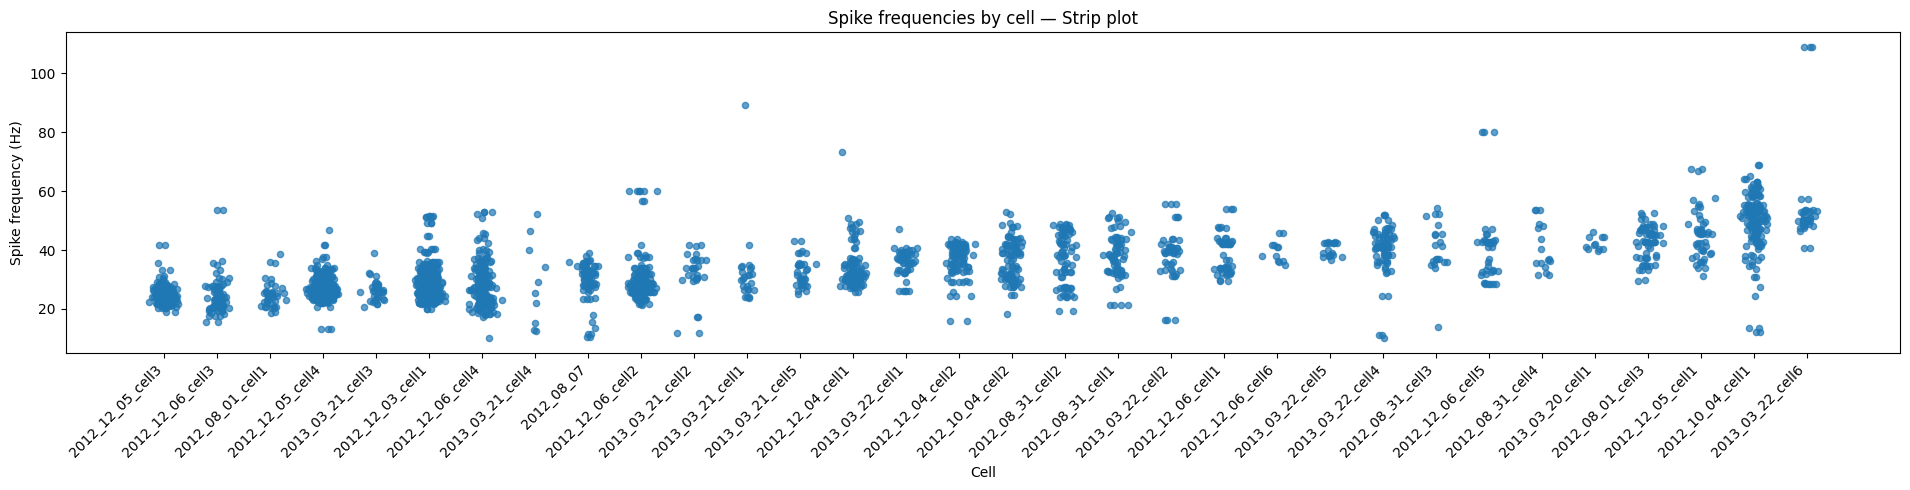

In [70]:
# Boxplot + jitter
plot_boxplot_spike_freq(all_spikes_clean)

# Strip plot
plot_strip_spike_freq(all_spikes_clean)


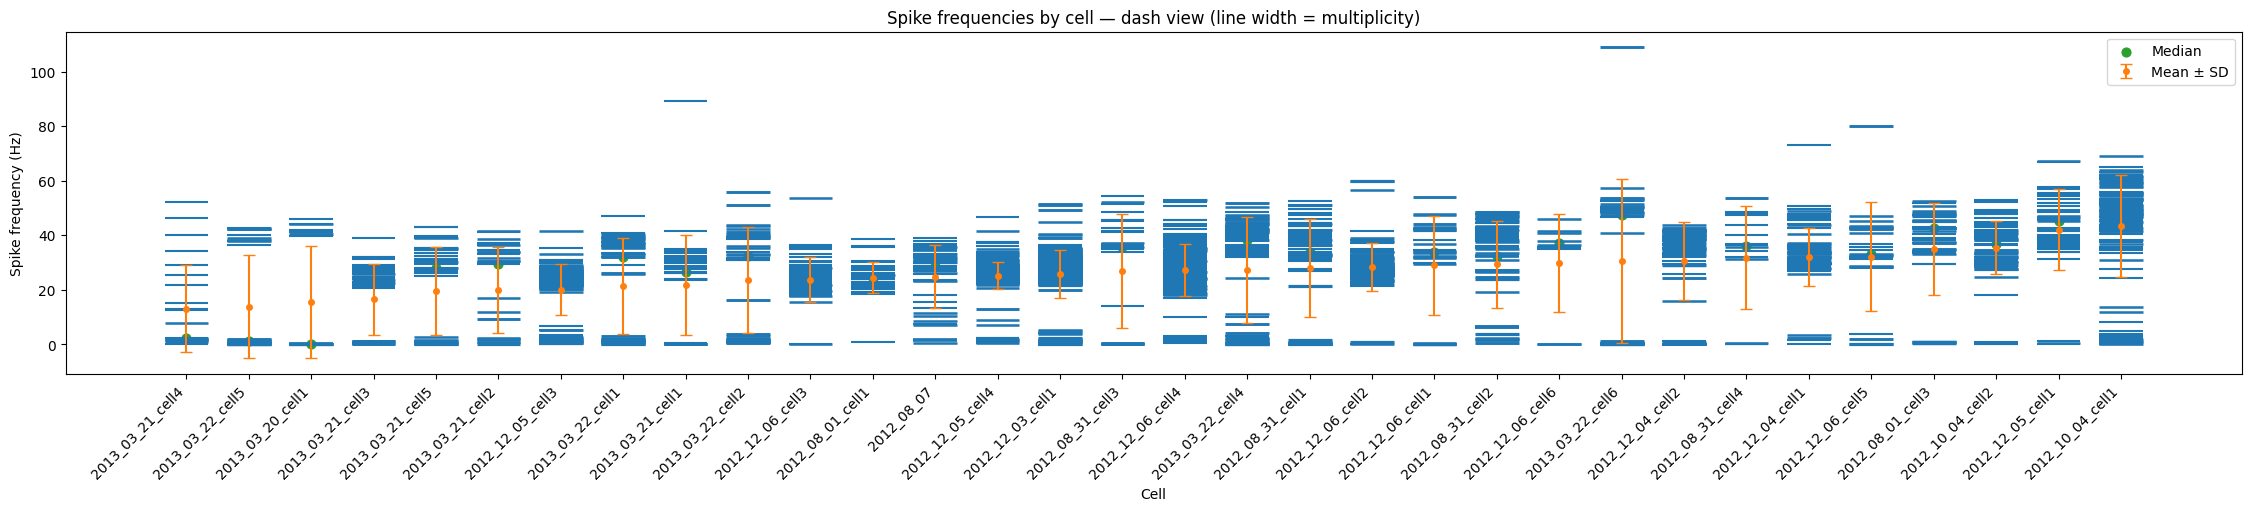

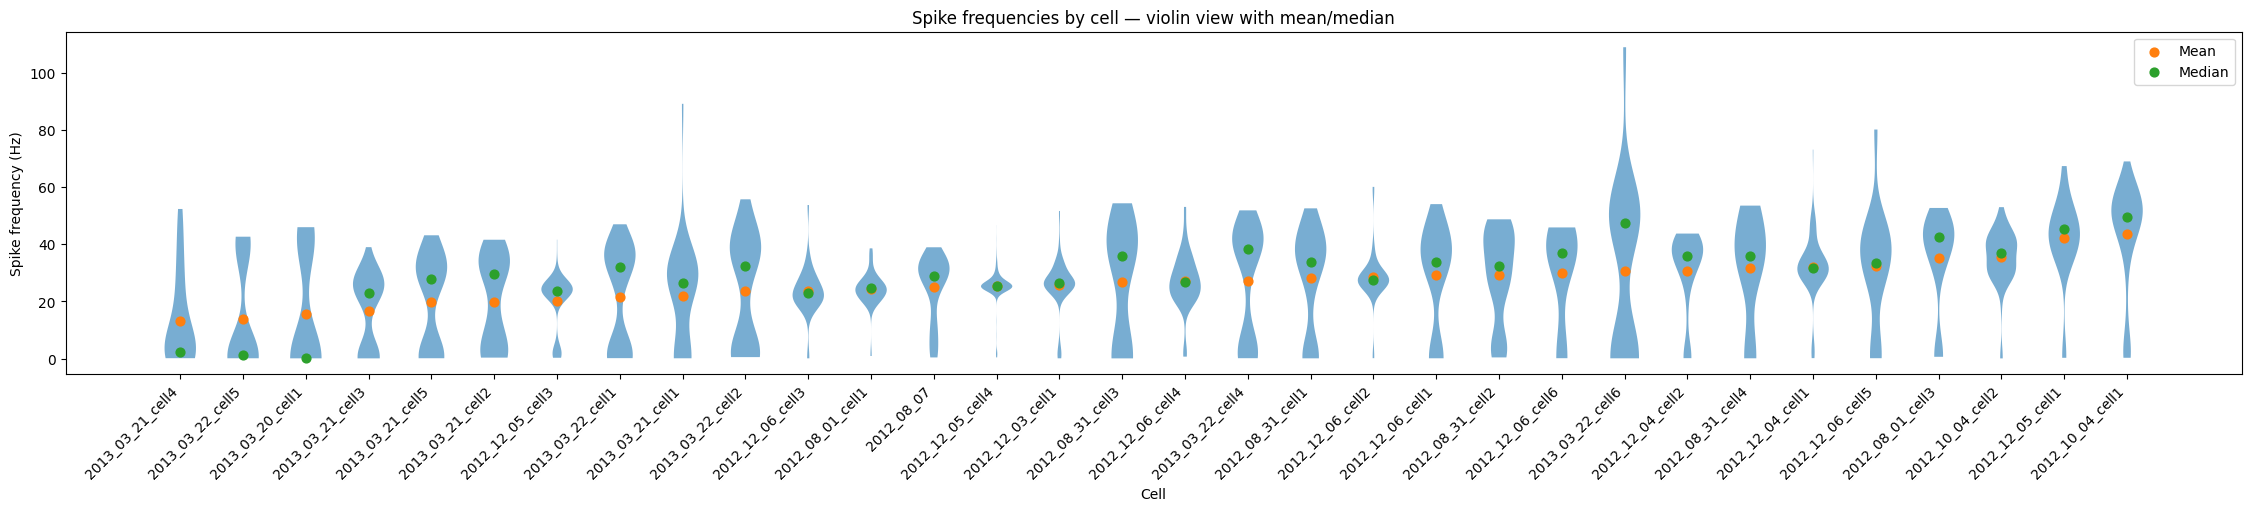

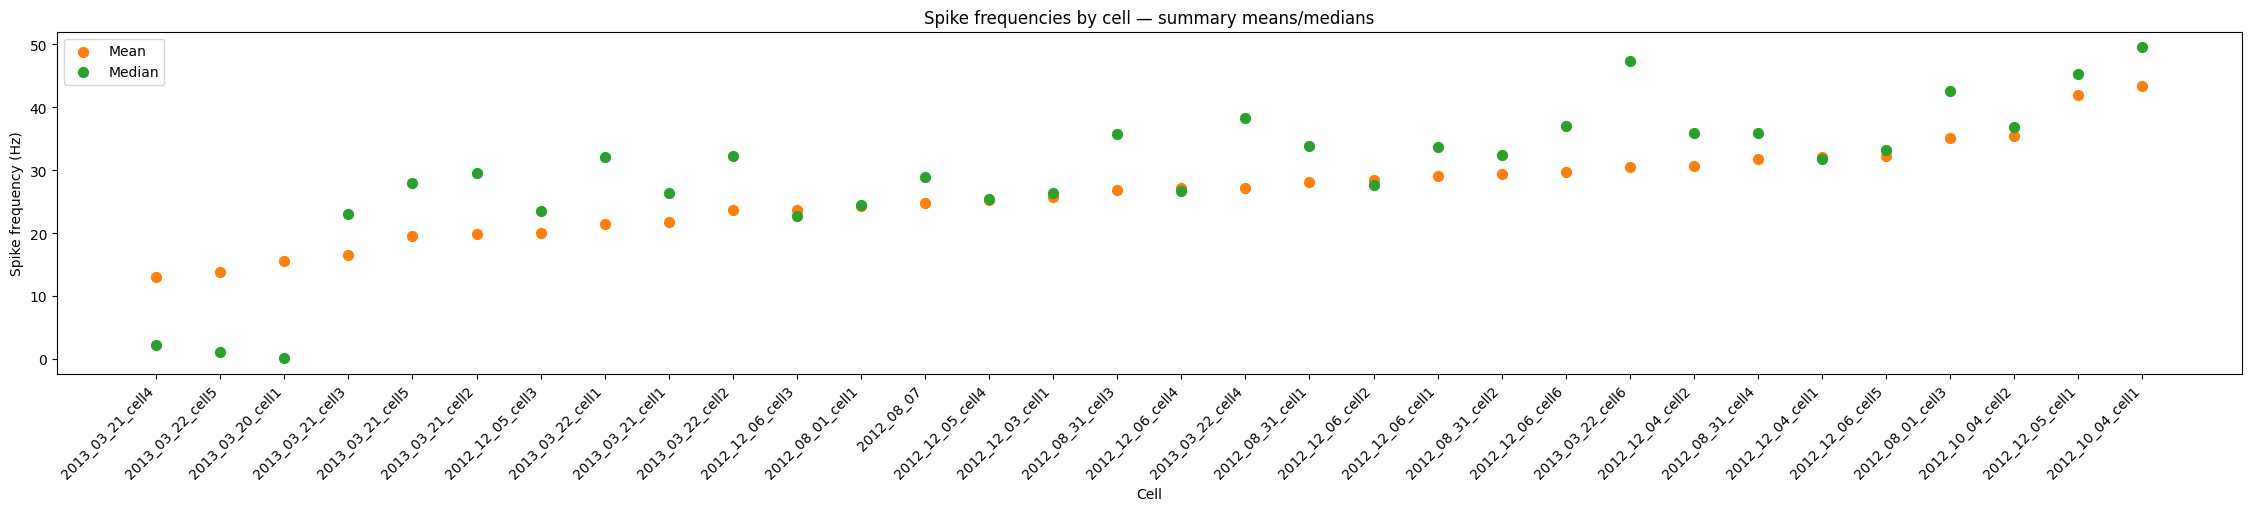

In [83]:
plot_all_views(all_spikes)

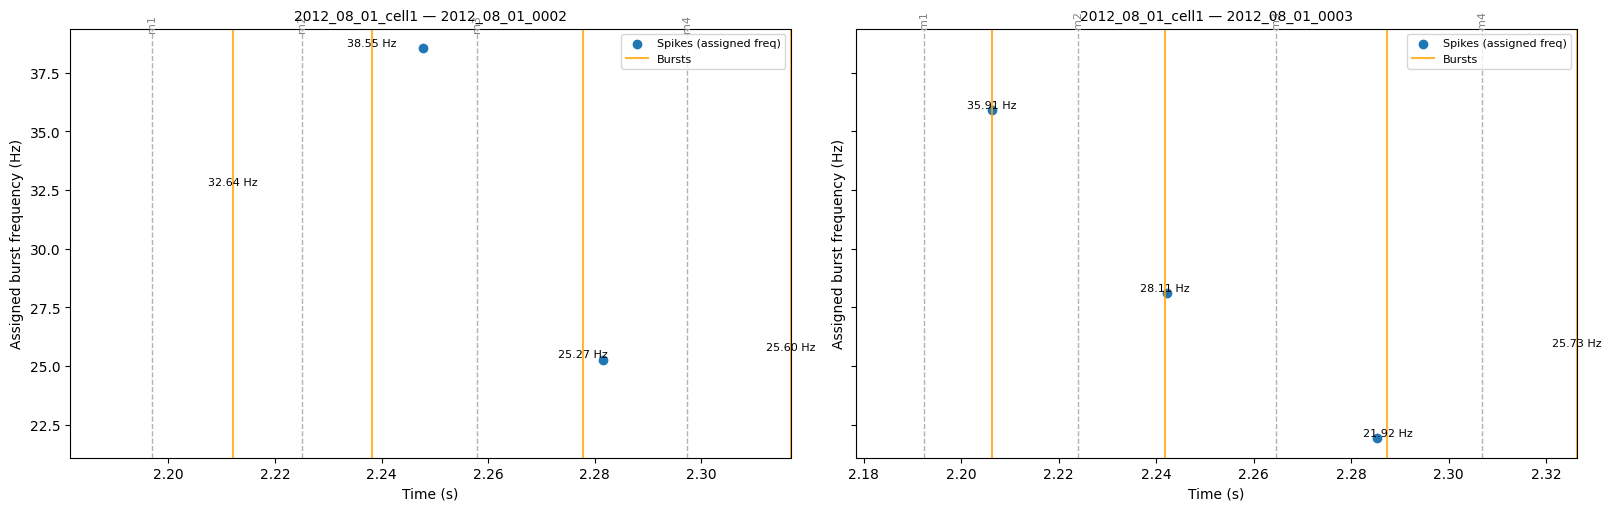

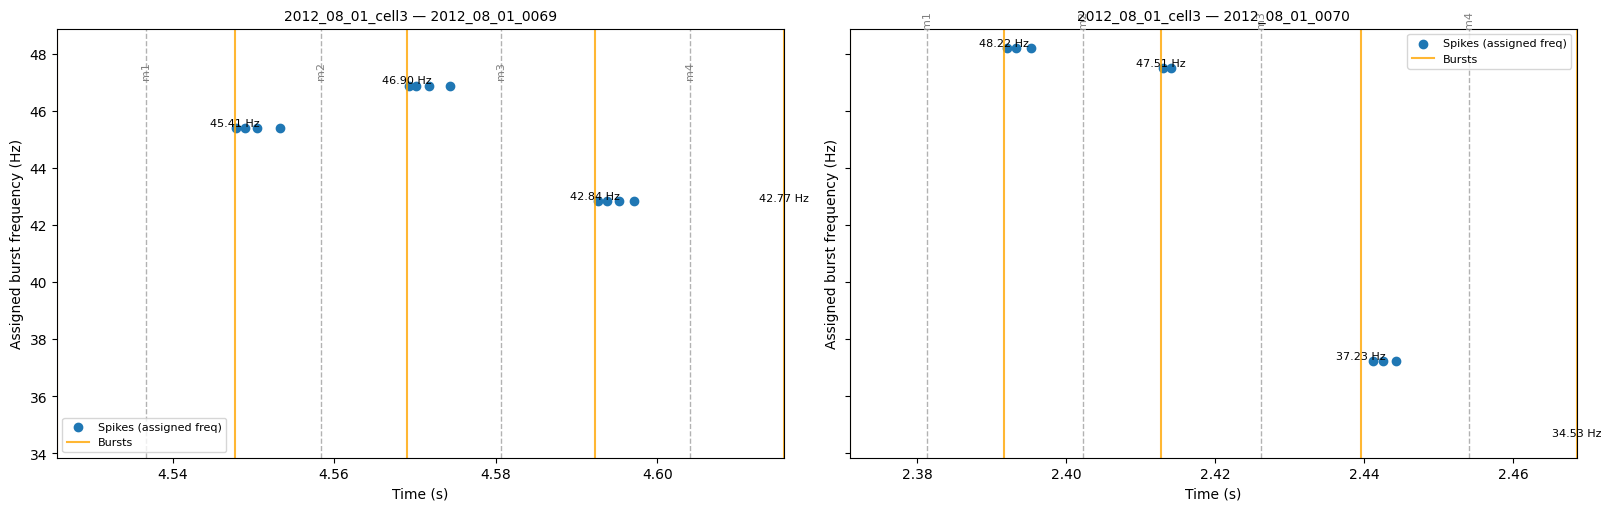

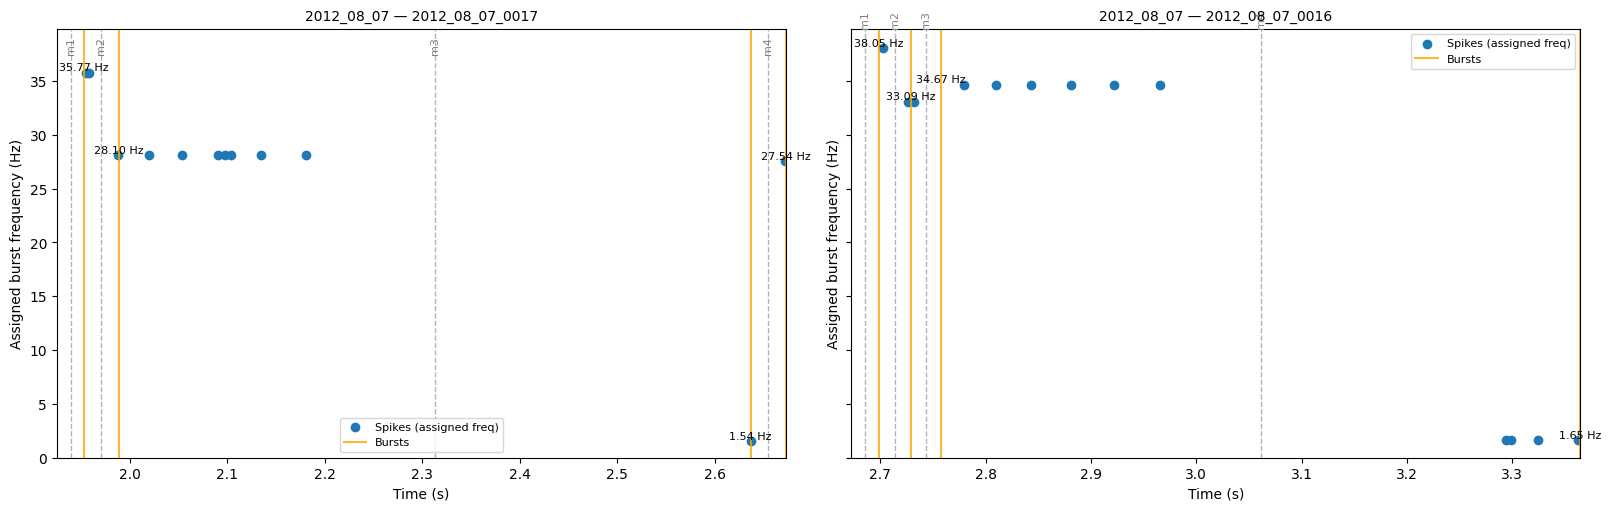

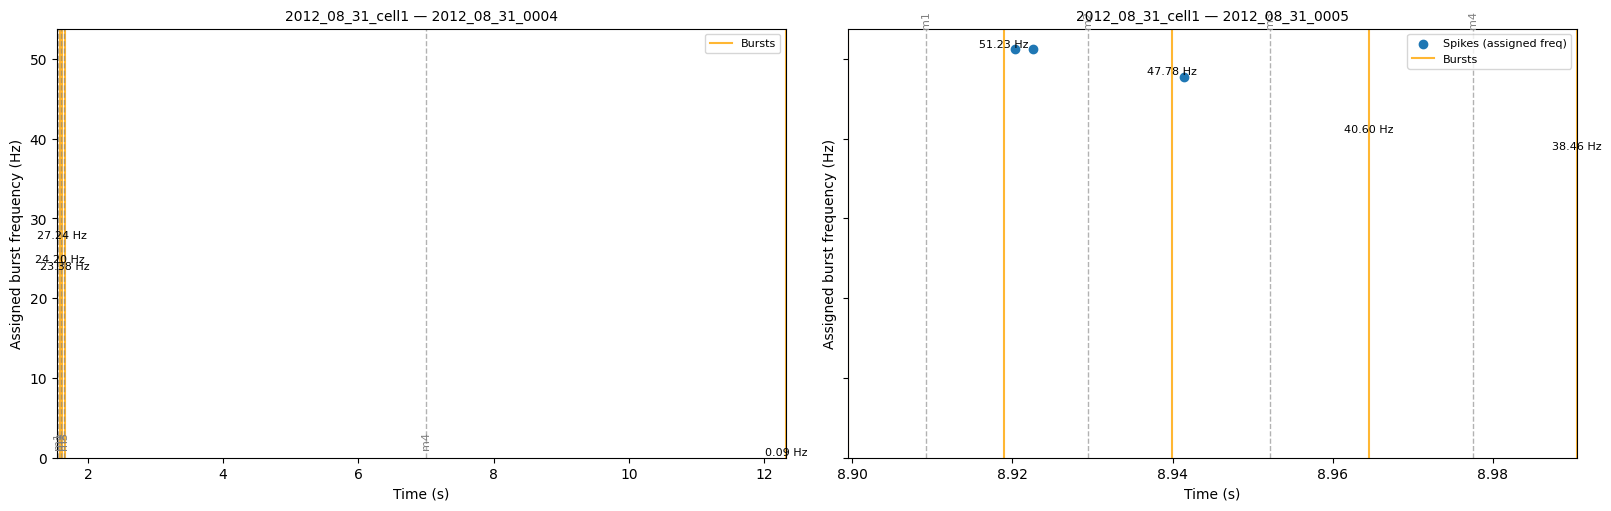

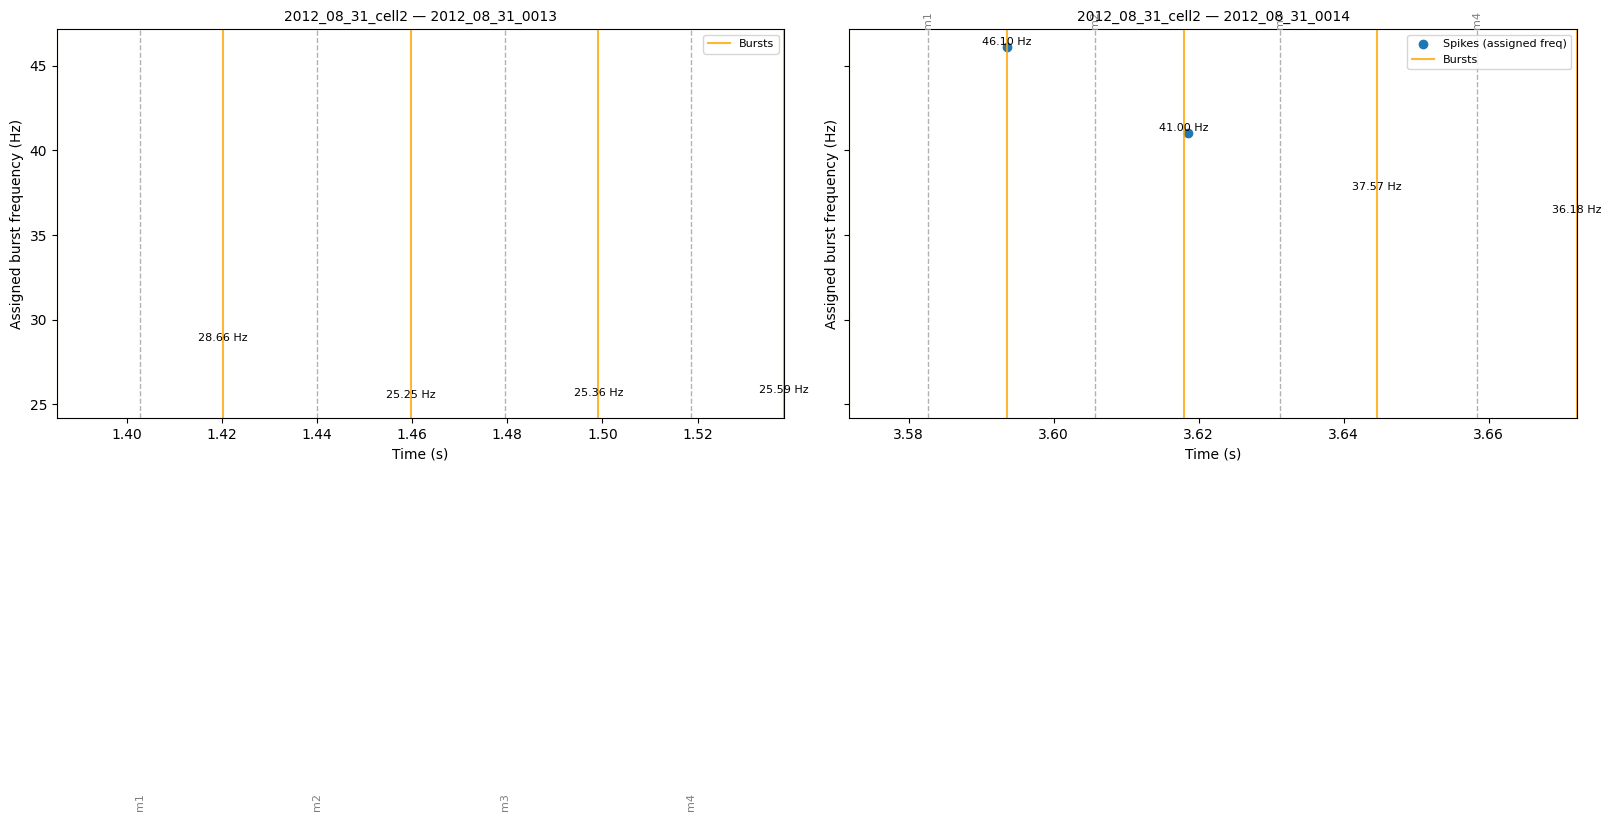

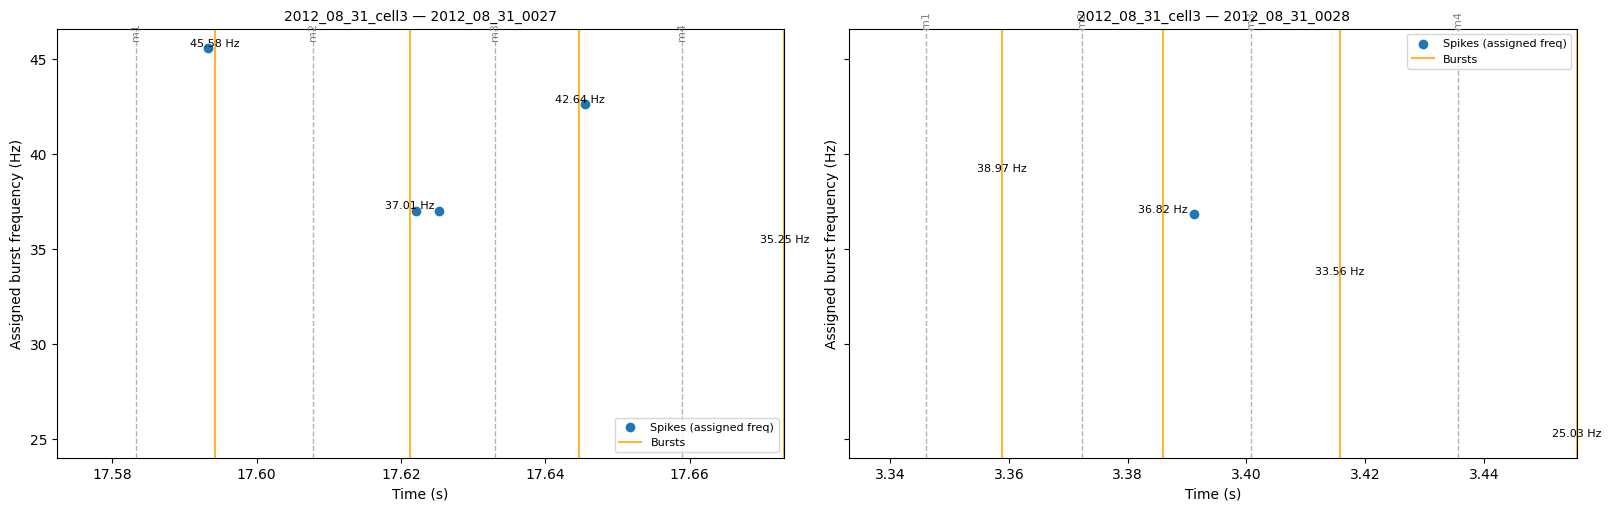

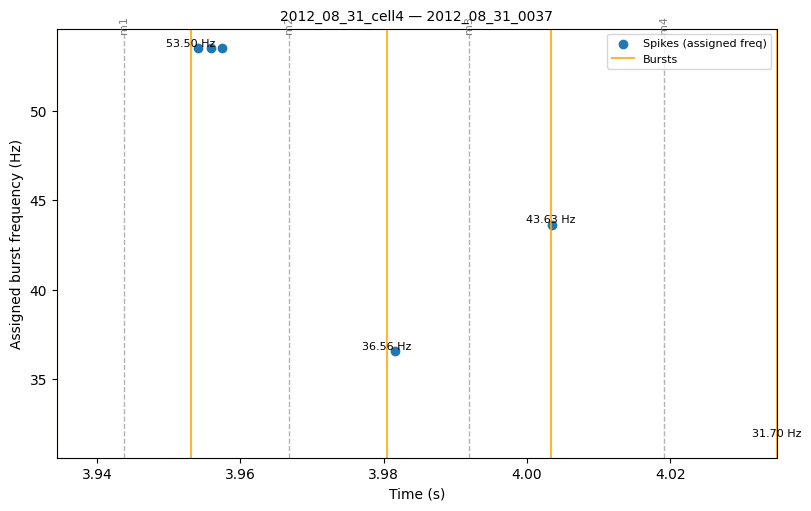

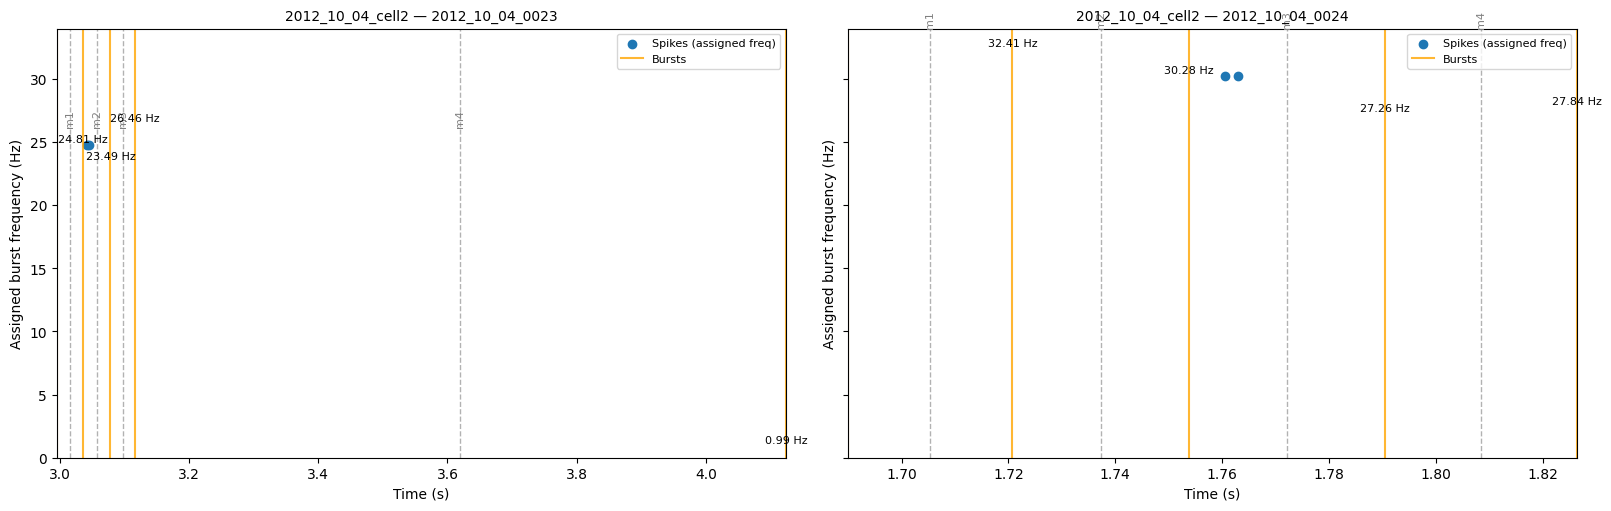

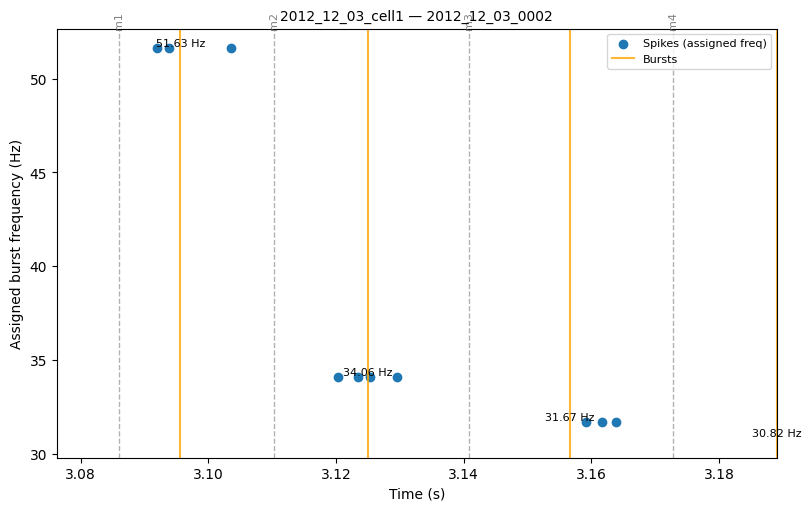

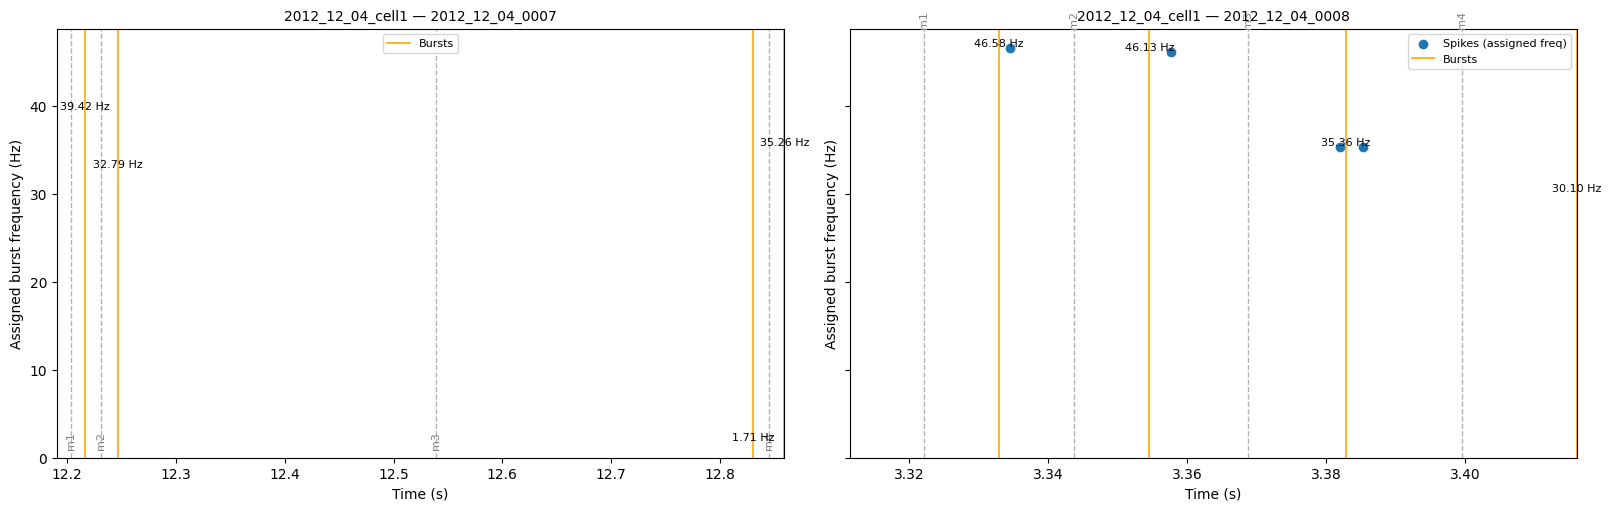

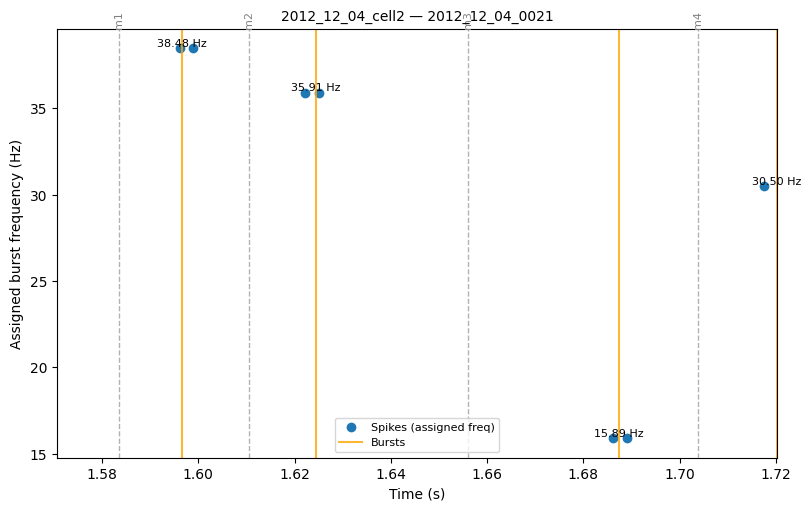

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


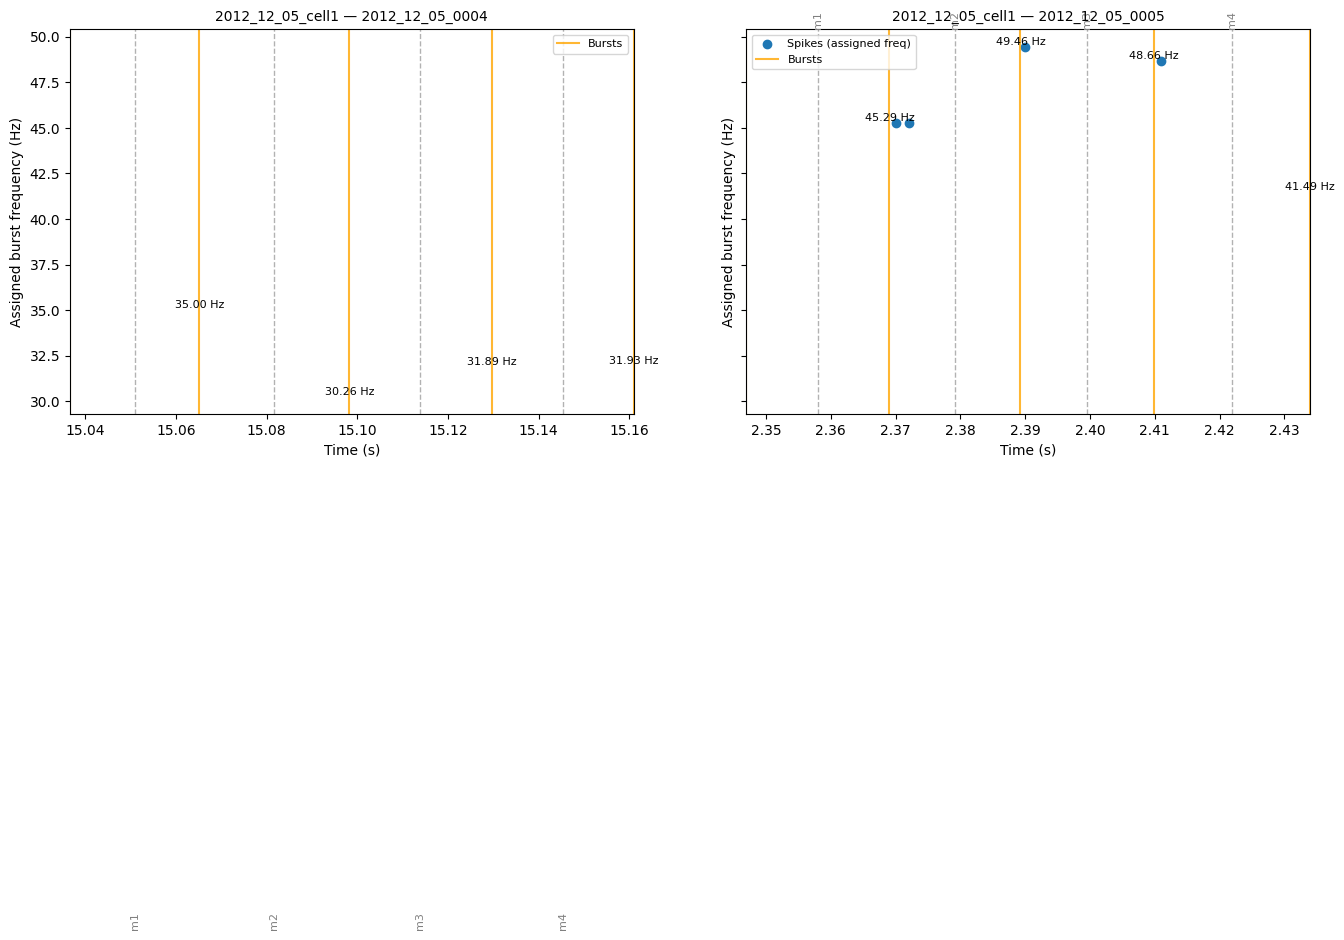

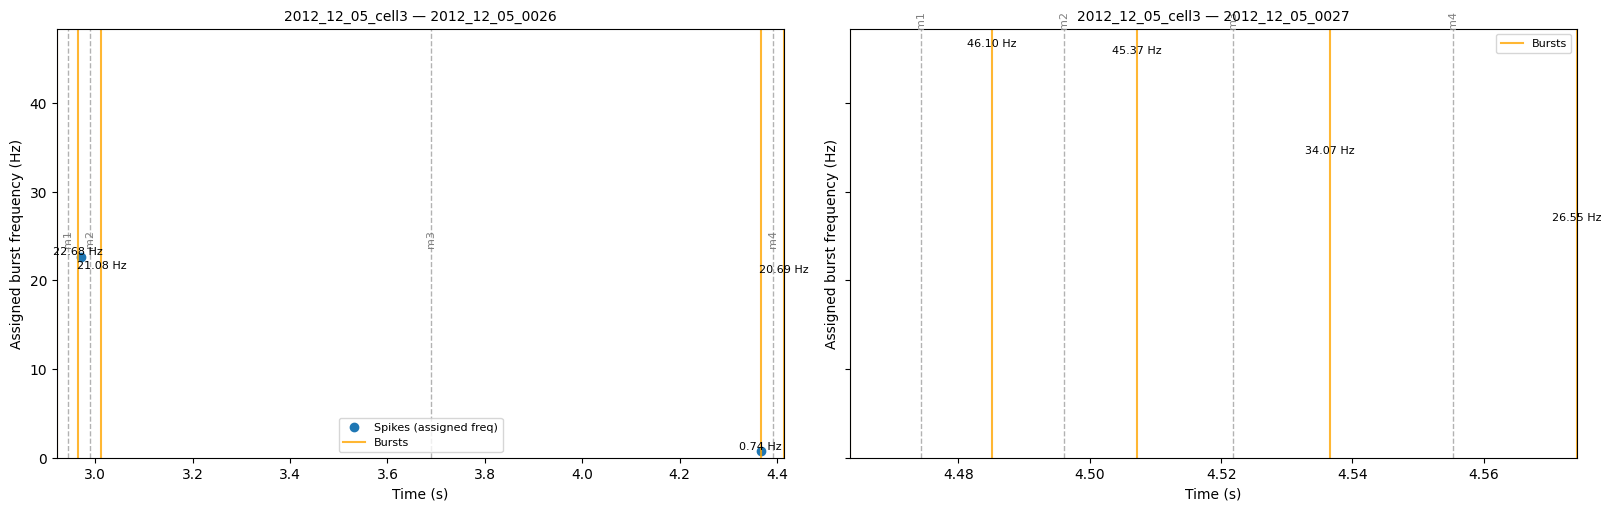

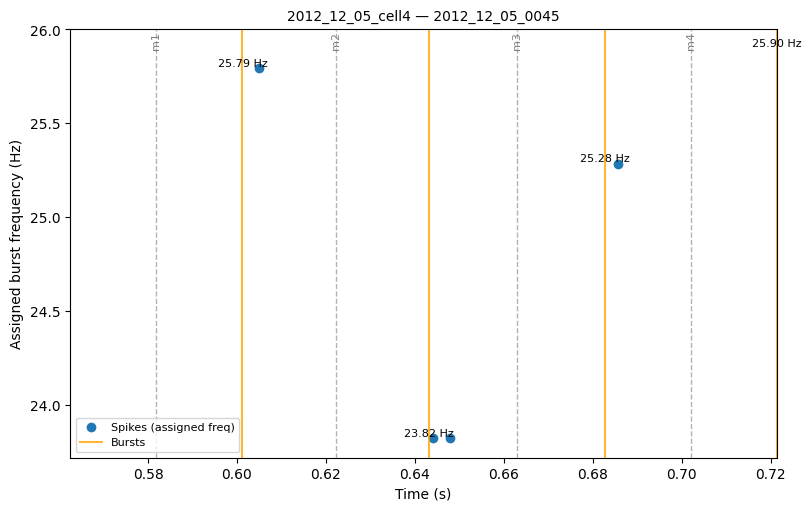

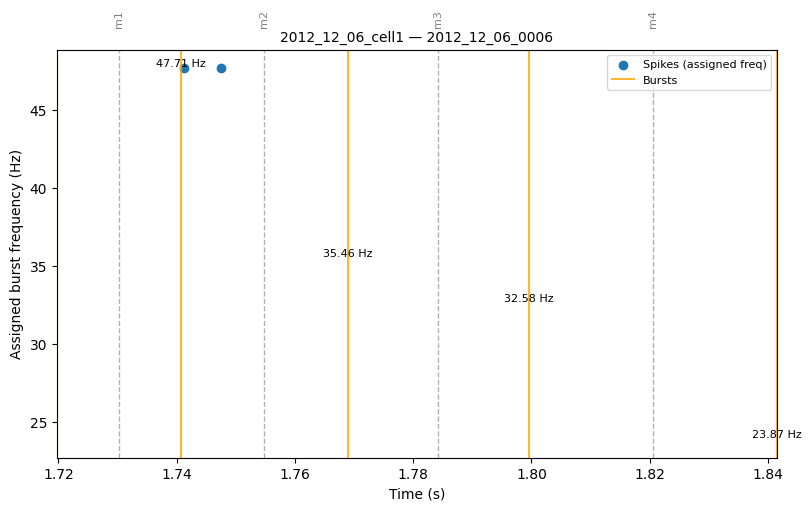

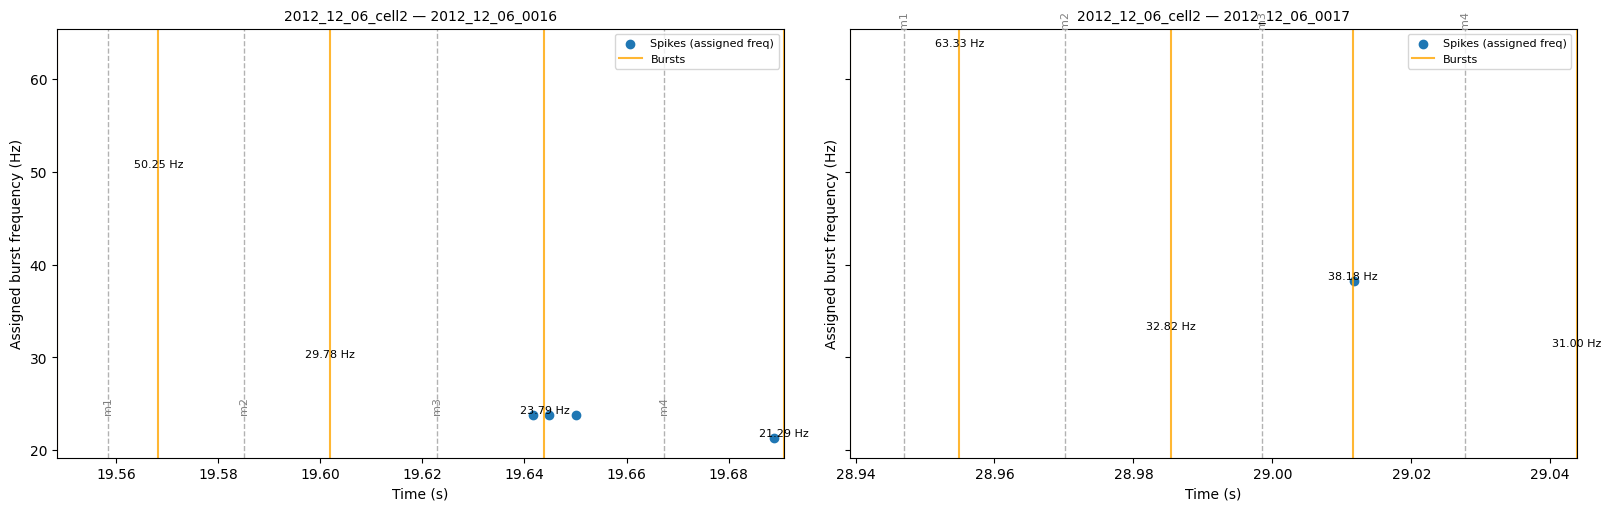

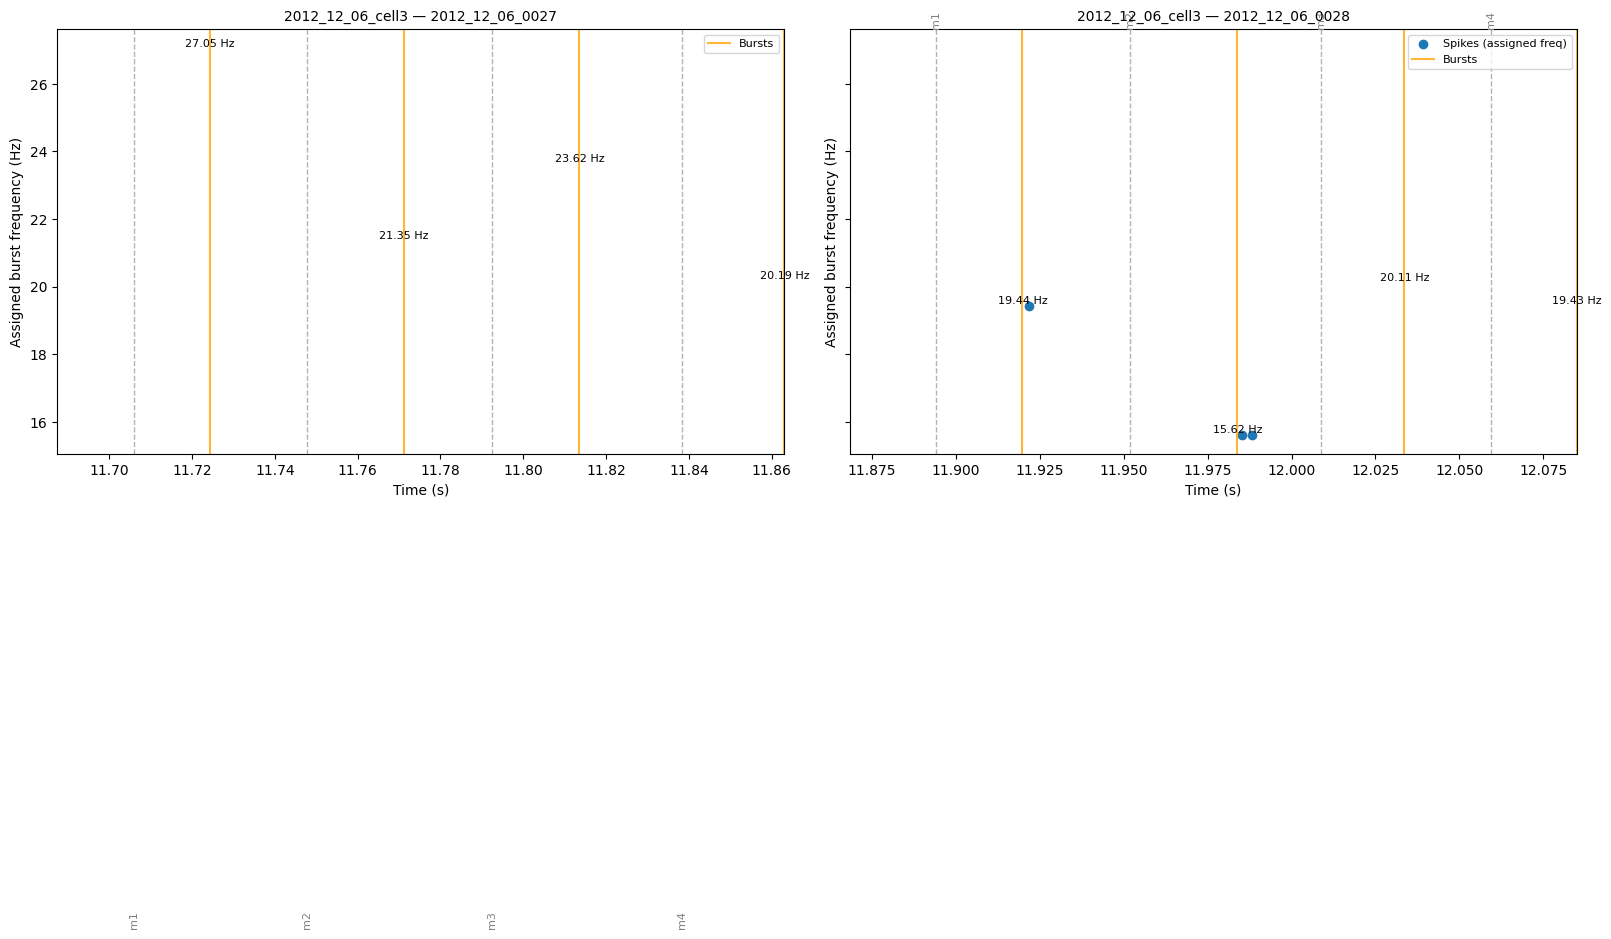

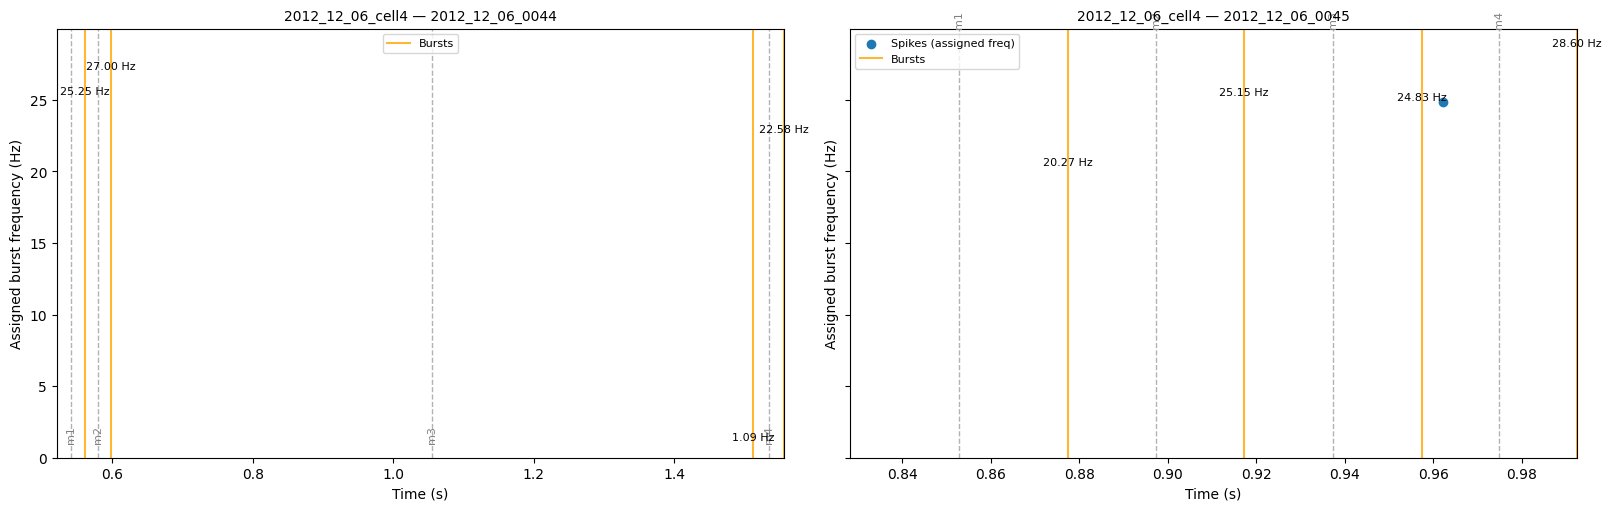

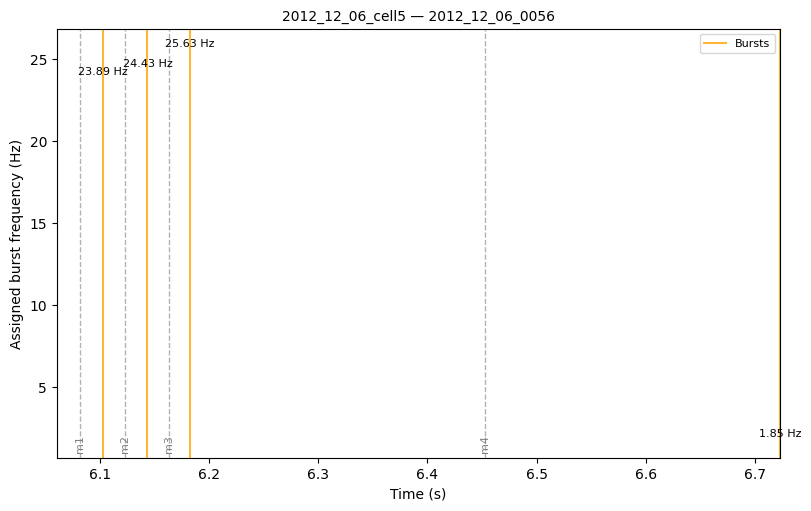

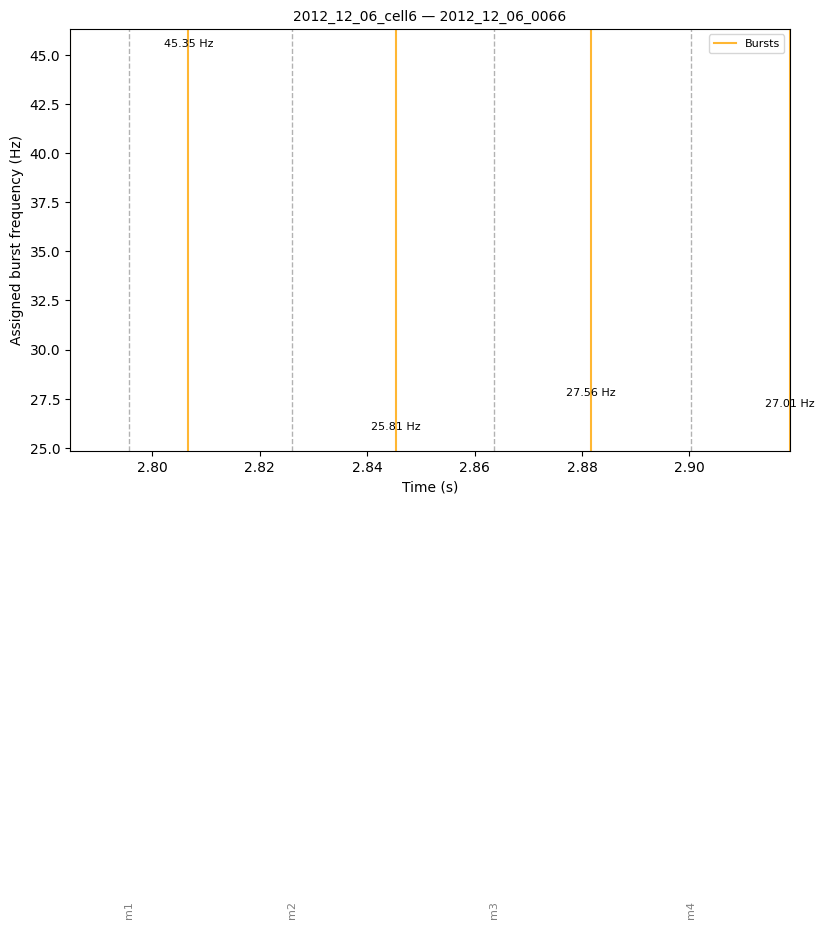

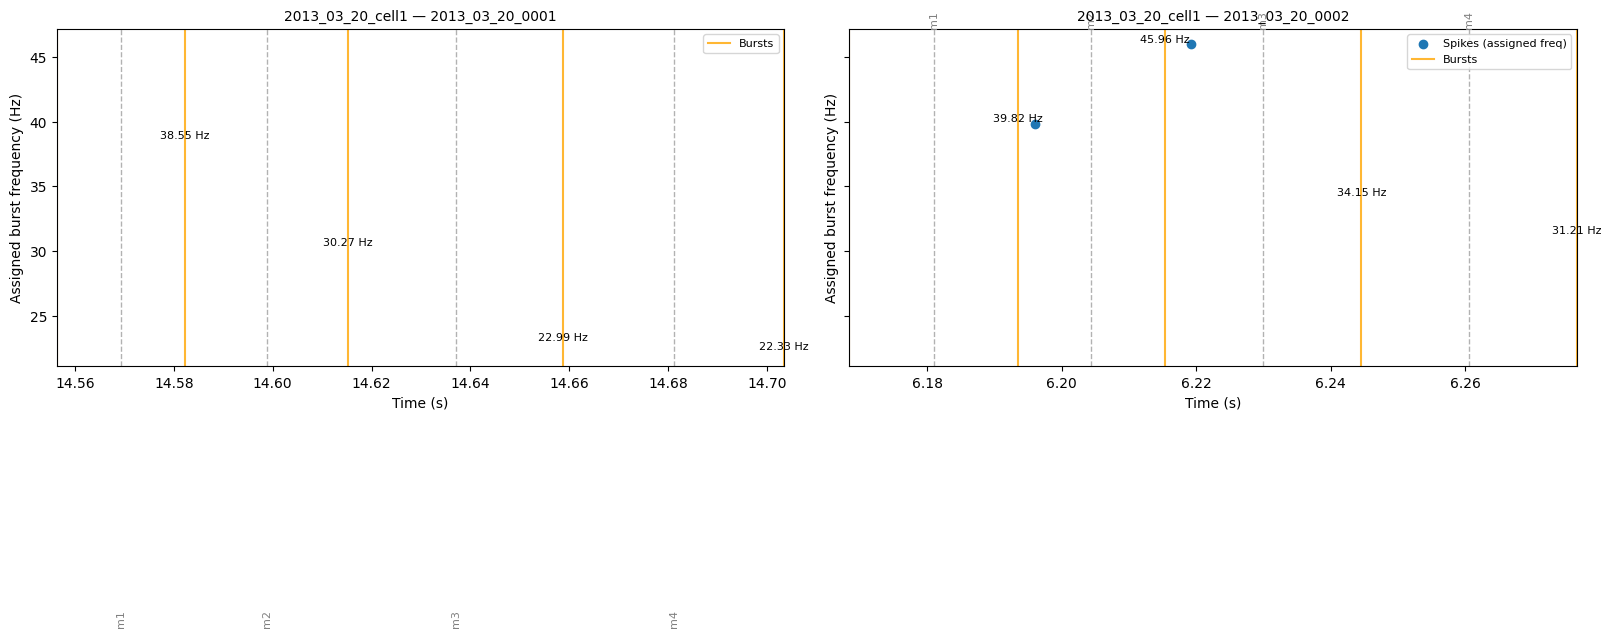

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


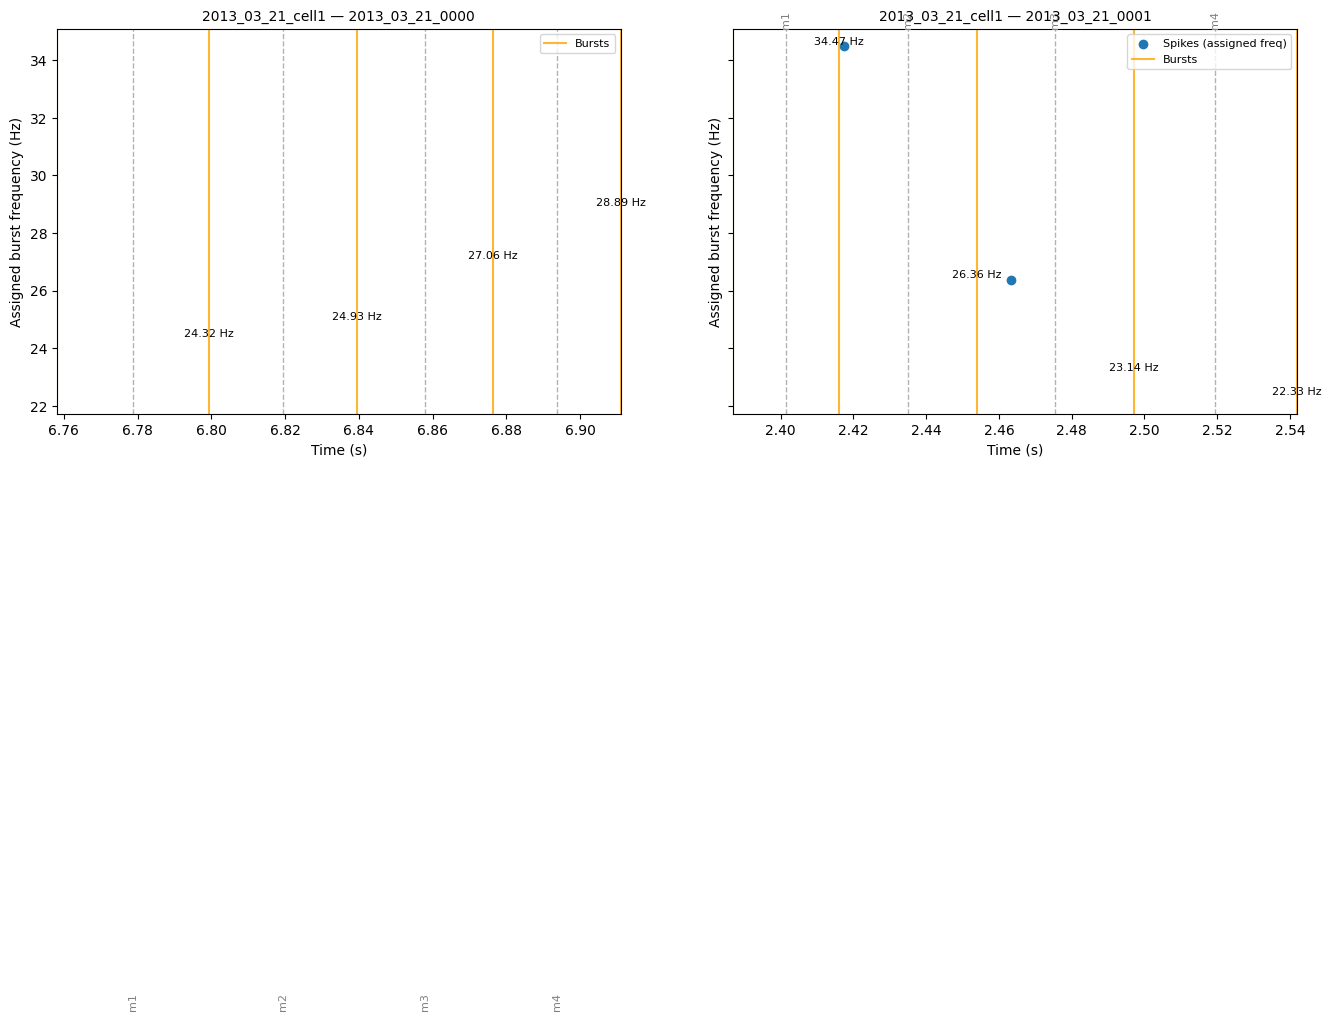

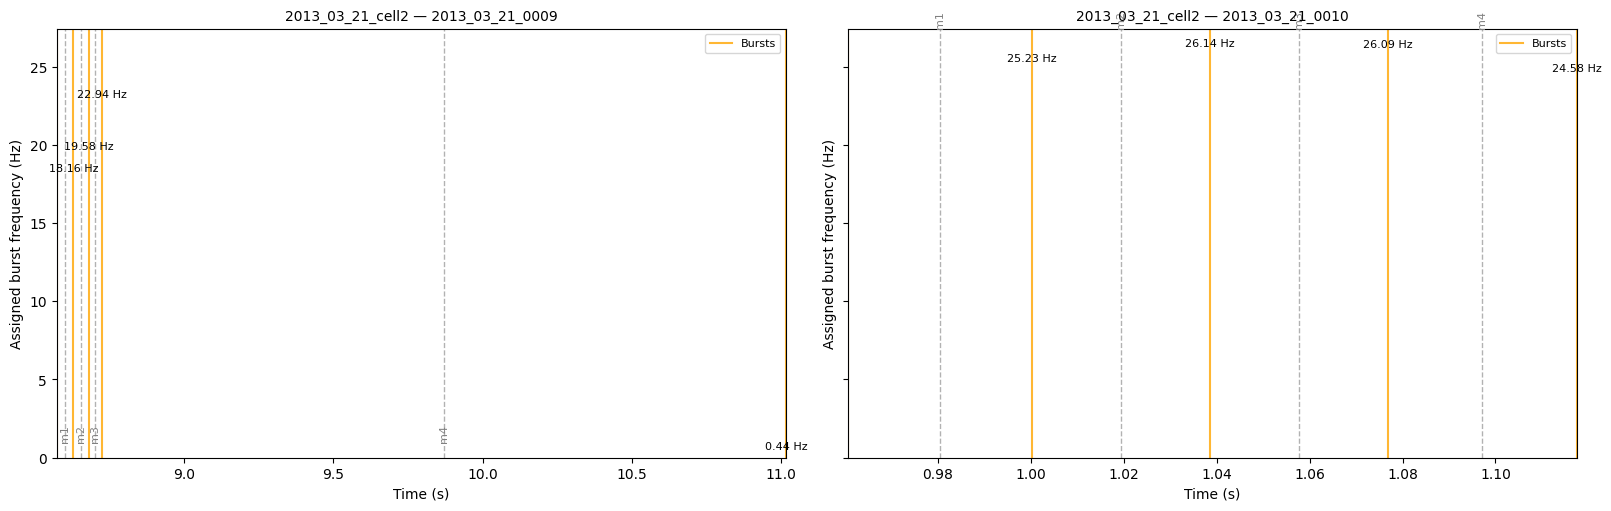

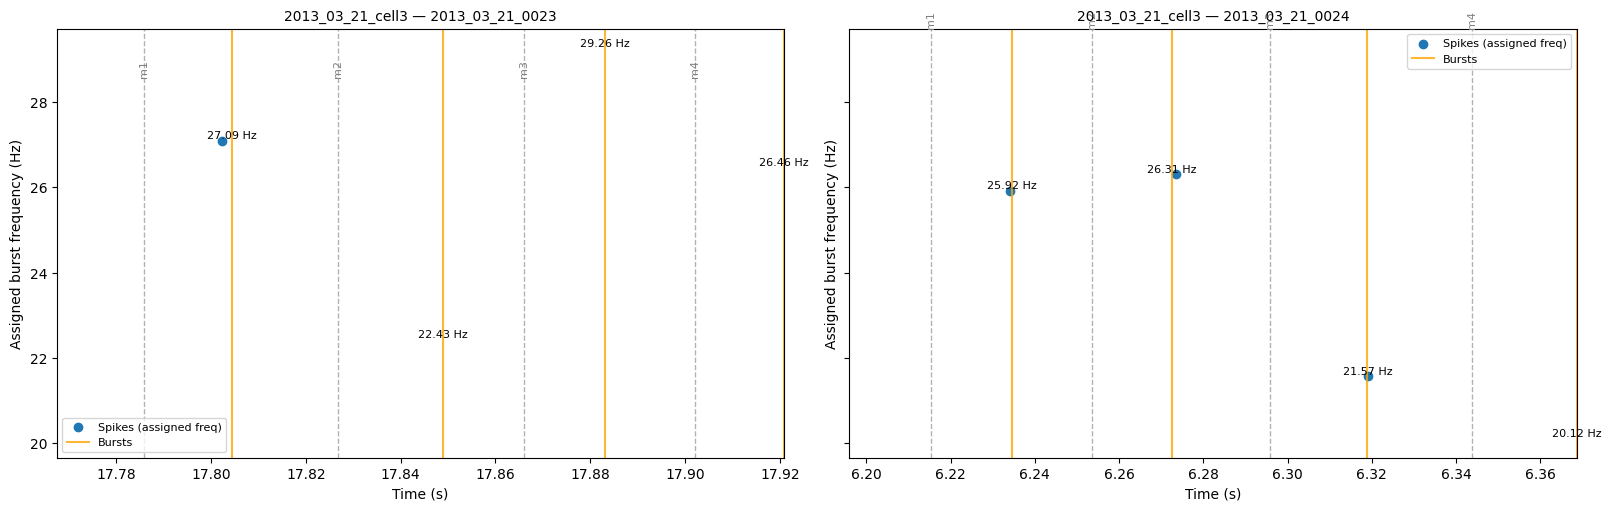

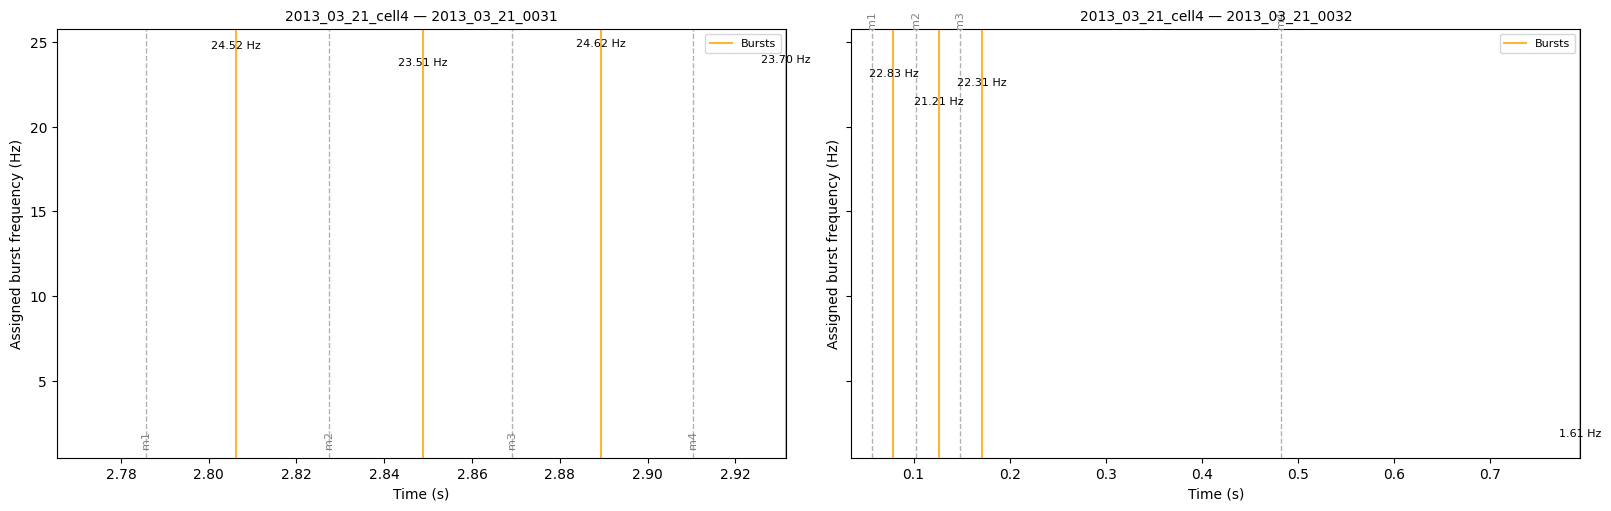

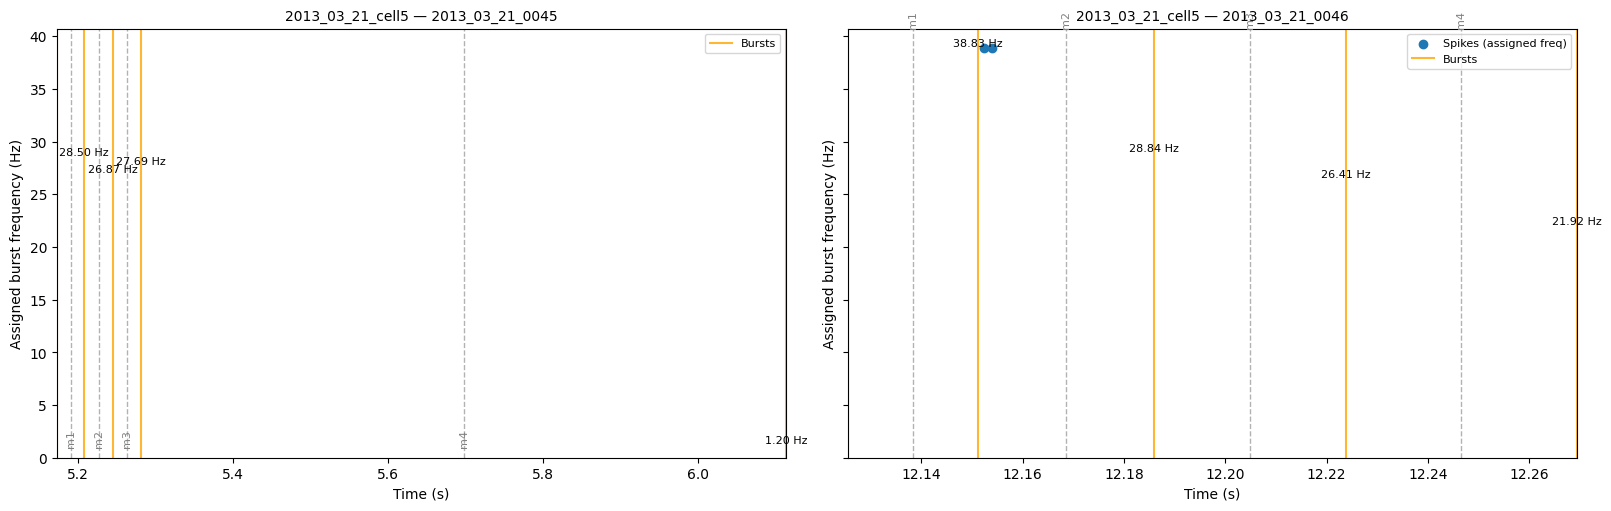

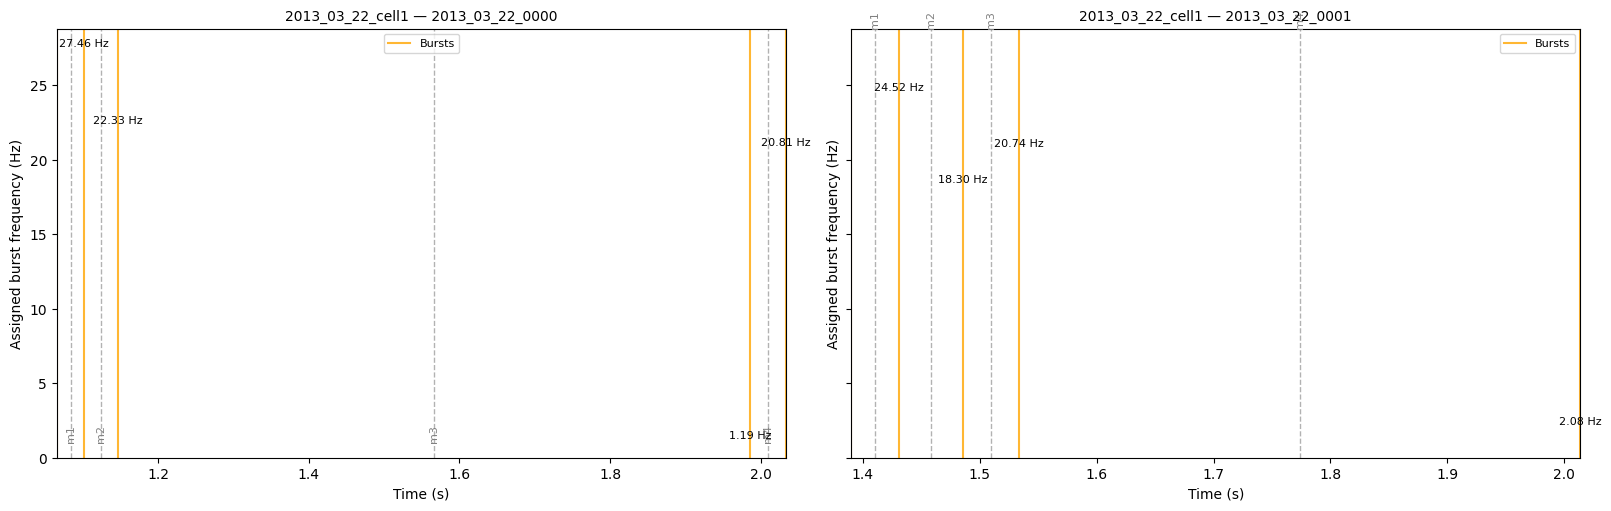

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


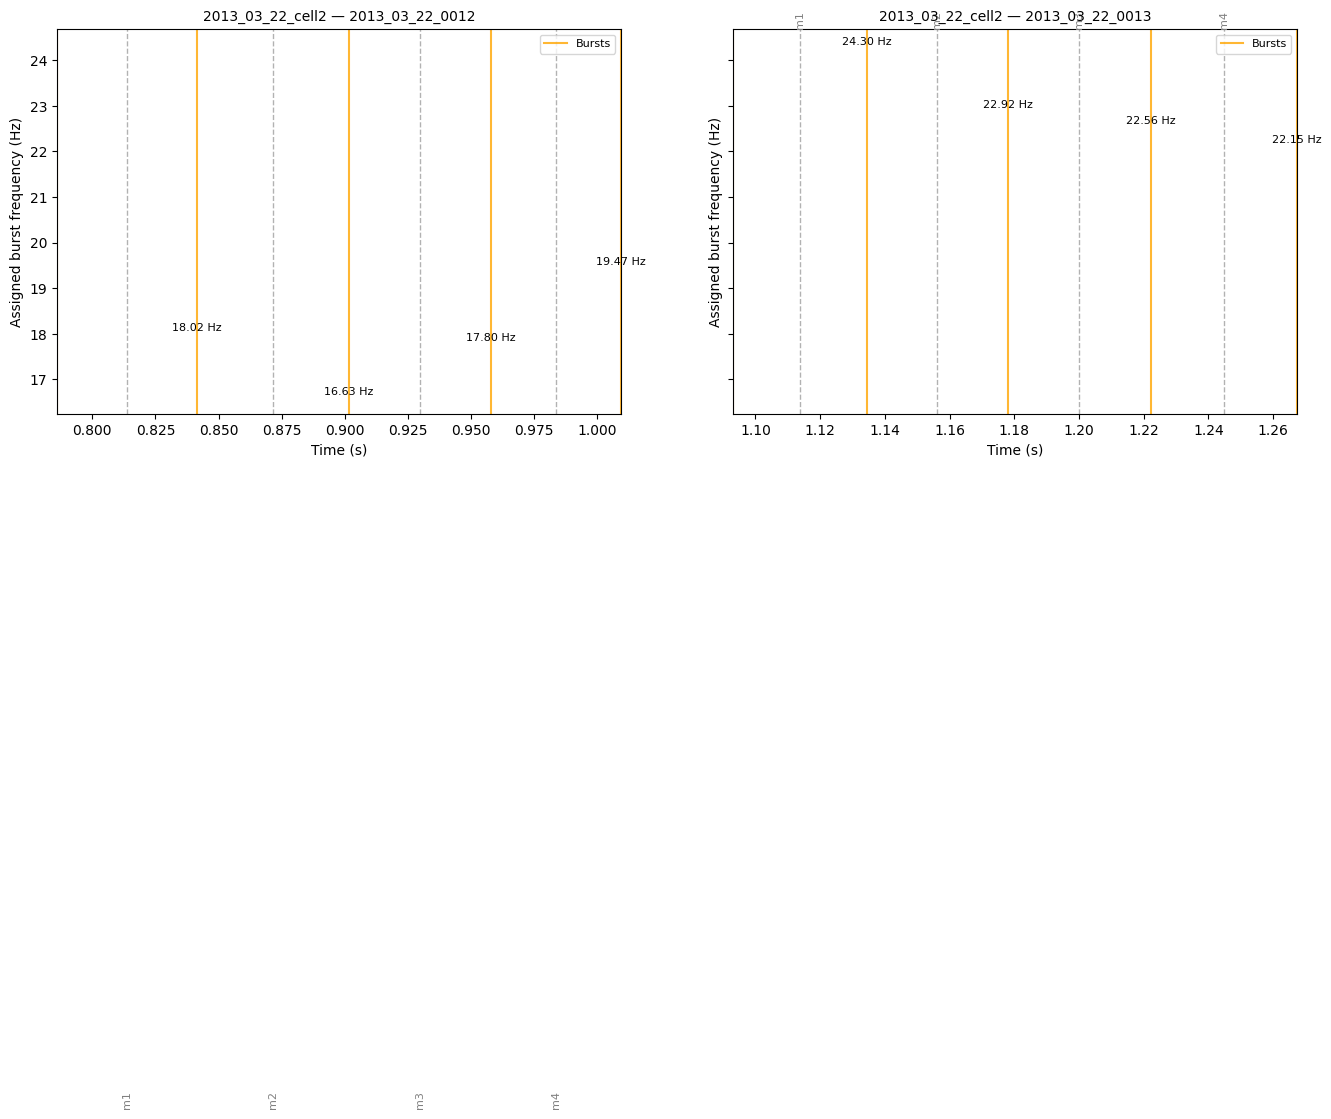

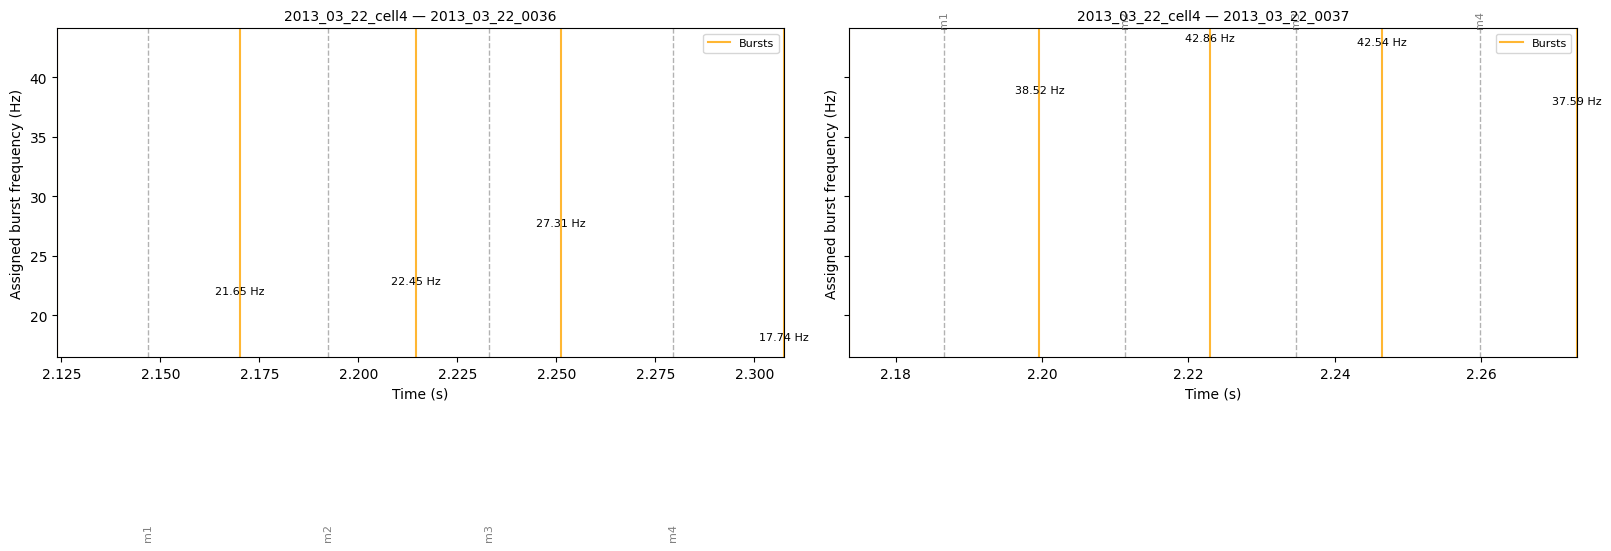

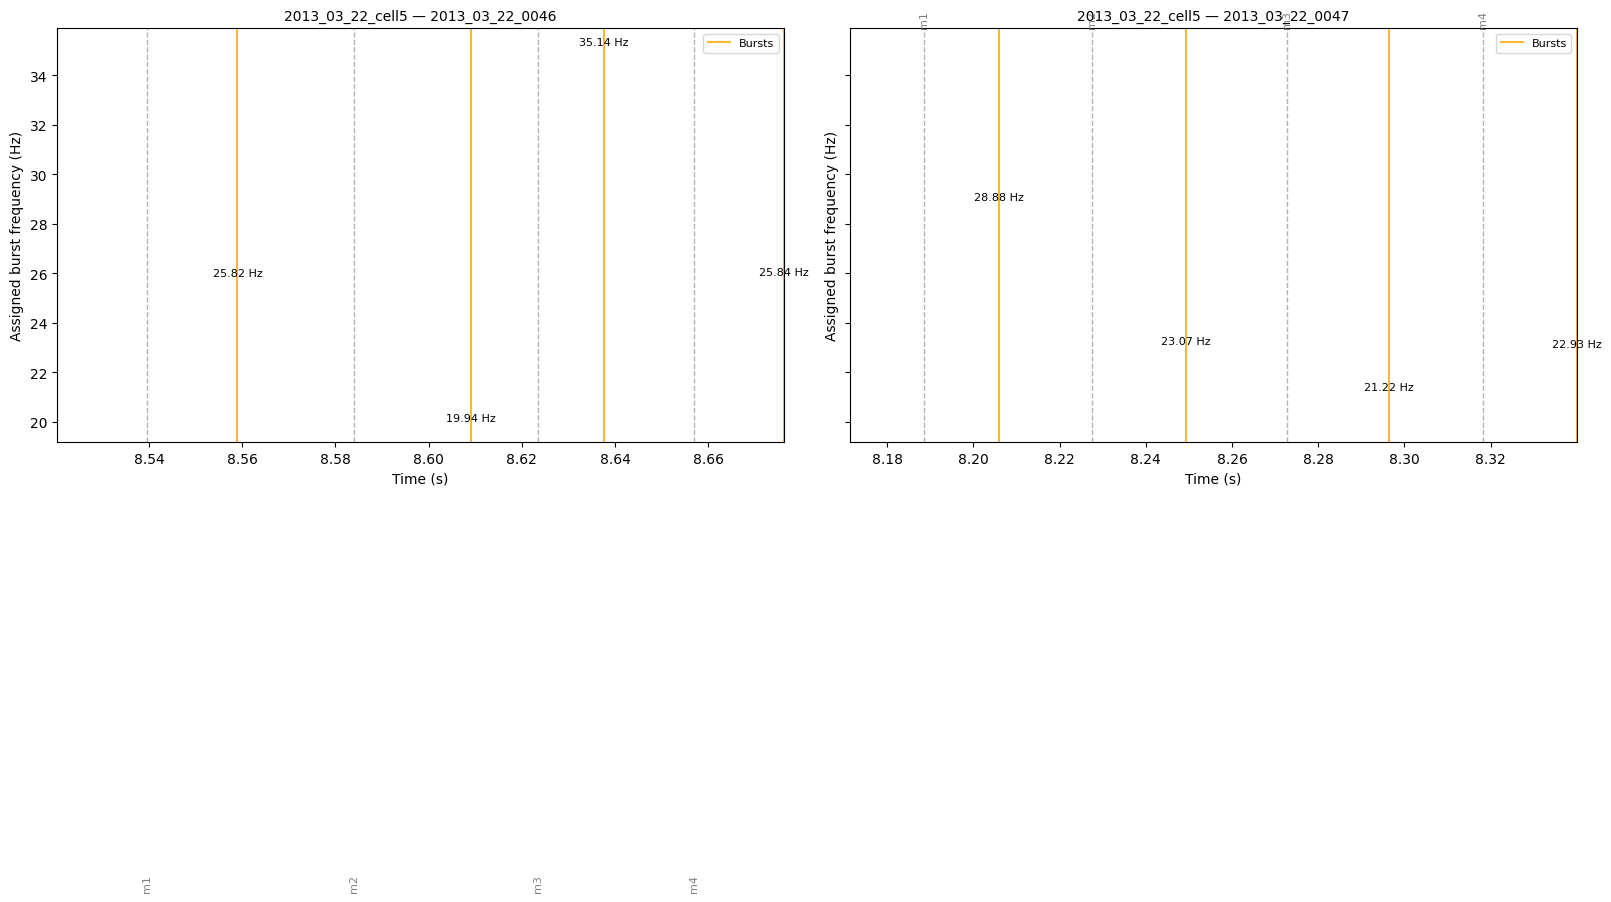

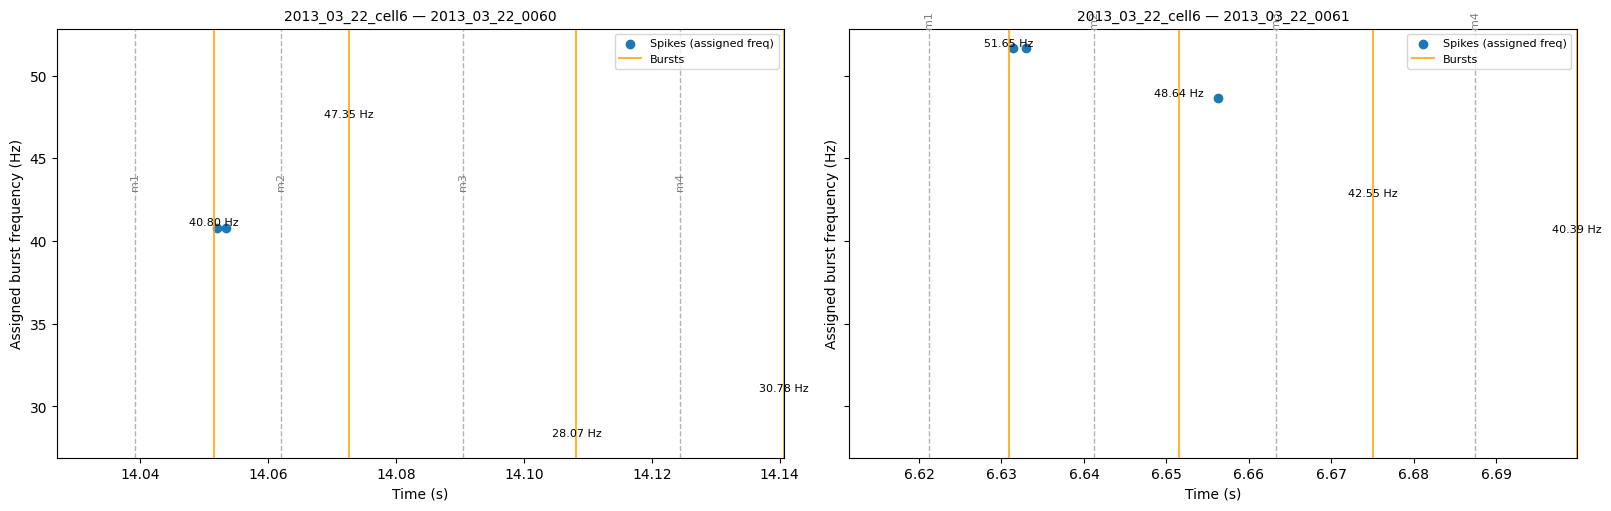

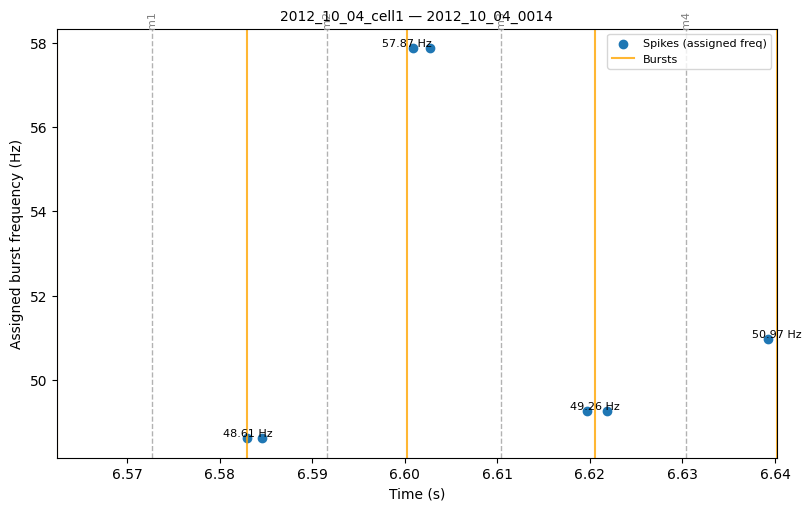

In [54]:
for sheet_name, sdf in cell_attached_dict.items():
    plot_sheet_first5_bursts(sdf, title_prefix=sheet_name)
